In [31]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, HDBSCAN
import matplotlib.pyplot as plt
import plotly.express as px
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [32]:
plt.rcParams.update({
    "font.size": 20,        # tamaño base
    "axes.titlesize": 24,   # título del gráfico
    "axes.labelsize": 22,   # labels de ejes
    "xtick.labelsize": 18,  # números eje X
    "ytick.labelsize": 18,  # números eje Y
    "legend.fontsize": 18,  # leyenda
    "figure.titlesize": 26  # título general de la figura
})

In [ ]:
# df = pd.read_csv("datos_resultados_modularizado/datos_clusterizados_todos_5dc3.csv")
df = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_resultados_modularizado\datos_clusterizados_todos_5d_f00.csv")
# df = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_resultados_modularizado\datos_clusterizados_todos_5d_trace.csv")
# df = df[df['grupo']>0]
df['division'] = df['coordenada_ra'].astype(str) + "_" + df['coordenada_dec'].astype(str)
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc
# Crear objetos SkyCoord vectorizados
coords = SkyCoord(ra=df['ra'].values * u.degree,
                  dec=df['dec'].values * u.degree,
                  distance=df['distance_pc'].values * u.pc,
                  frame='icrs')

# Extraer coordenadas cartesianas
df['x_pc'] = coords.cartesian.x.value
df['y_pc'] = coords.cartesian.y.value
df['z_pc'] = coords.cartesian.z.value

In [ ]:
df['probabilidad'] = df['ConteoAgrupaciones']/400

In [4]:
df['l'] = coords.galactic.l.degree  # longitud galáctica
df['b'] = coords.galactic.b.degree 
df['l_rad'] = np.radians(df['l'].values - 180)   # longitud galáctica
df['b_rad'] = np.radians(df['b'].values)

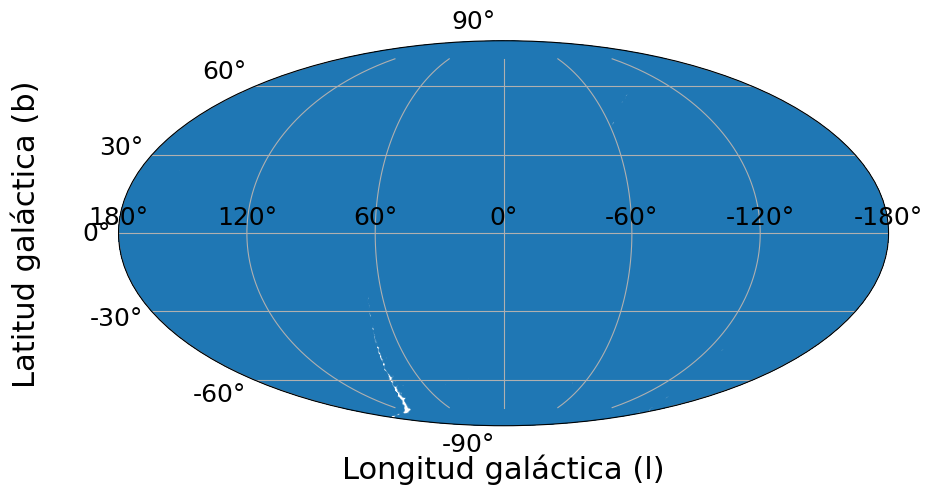

In [5]:
l = df['l'].values
b = df['b'].values

# Convertir a radianes para Mollweide
l_rad = np.radians(l - 180)  # Recentrar en 0°
b_rad = np.radians(b)

# Crear figura
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

# Scatter plot
ax.scatter(l_rad, b_rad, s=5, alpha=0.7)

# Grid cada 30° latitud, 60° longitud
ax.set_xticks(np.radians(np.arange(-180, 181, 60)))
ax.set_yticks(np.radians(np.arange(-90, 91, 30)))

ax.set_xticklabels(['180°', '120°', '60°', '0°', '-60°', '-120°', '-180°'])
ax.set_yticklabels(['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°'])

ax.grid(True)
ax.set_xlabel('Longitud galáctica (l)', labelpad=20)
ax.set_ylabel('Latitud galáctica (b)', labelpad=30)
plt.show()

In [6]:
def silhouette_por_cluster_dataframe(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    feature_cols: list = None
) -> pd.Series:
    """
    Calcula el coeficiente silhouette promedio por clúster.
    
    Computa la métrica de silhouette para cada muestra sobre características
    especificadas, luego agrupa por clúster para obtener el valor promedio.
    Excluye automáticamente datos etiquetados como ruido (cluster_col == -1).
    
    Args:
        df: DataFrame con datos de estrellas y etiquetas de clúster.
        cluster_col: Nombre de la columna que contiene las etiquetas de clúster.
            Default: 'cluster'.
        feature_cols: Lista de columnas a usar como características para silhouette.
            Si es None, se detectan automáticamente todas las columnas numéricas.
            Default: None.
    
    Returns:
        Series indexada por cluster_col con el silhouette promedio por clúster.
        Unidades: [-1, 1] donde 1 indica clúster perfectamente separado.
    
    Raises:
        ValueError: Si feature_cols contiene columnas que no existen en df.
    
    Example:
        >>> silhouette = silhouette_por_cluster_dataframe(
        ...     df, cluster_col='cluster', feature_cols=['x', 'y', 'z']
        ... )
    """
    # Excluir ruido
    df_valido = df[df[cluster_col] != -1].copy()

    if feature_cols is None:
        # Detectar columnas numéricas automáticamente si no se especifican
        feature_cols = df_valido.select_dtypes(include=['float64', 'int64']).columns.tolist()
        feature_cols.remove(cluster_col)

    X = df_valido[feature_cols].values
    labels = df_valido[cluster_col].values

    # Calcular silhouette por muestra
    sil_values = silhouette_samples(X, labels)

    df_valido['silhouette'] = sil_values

    # Agrupar por clúster y calcular promedio
    silhouette_mean = df_valido.groupby(cluster_col)['silhouette'].mean()

    return silhouette_mean

def r2_por_cluster_dataframe(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    x_col: str = 'bp_rp',
    y_col: str = 'phot_g_mean_mag',
    calcular_rmse: bool = True,
    calcular_residual_std: bool = True
) -> pd.DataFrame:
    """
    Ajusta regresión lineal por clúster y calcula métricas de bondad de ajuste.
    
    Para cada clúster (excluyendo ruido), realiza una regresión lineal de y_col
    sobre x_col y computa R², RMSE y desviación estándar de residuos.
    
    Args:
        df: DataFrame con datos de estrellas.
        cluster_col: Nombre de la columna de clústers. Default: 'cluster'.
        x_col: Nombre de la variable independiente. Default: 'bp_rp'.
        y_col: Nombre de la variable dependiente. Default: 'phot_g_mean_mag'.
        calcular_rmse: Si True, calcula RMSE (Mean Squared Error). Default: True.
        calcular_residual_std: Si True, calcula desviación estándar de residuos.
            Default: True.
    
    Returns:
        DataFrame con columnas [cluster_col, 'r2', 'rmse_{y}_vs_{x}', 
        'std_residuos_{y}_vs_{x}']. Una fila por clúster con al menos 2 
        observaciones.
    
    Raises:
        ValueError: Si x_col o y_col no existen en df.
    
    Example:
        >>> r2_results = r2_por_cluster_dataframe(
        ...     df, cluster_col='cluster', x_col='bp_rp', y_col='phot_g_mean_mag'
        ... )
    """
    df_valido = df[df[cluster_col] != -1].copy()
    resultados = []

    for cluster, grupo in df_valido.groupby(cluster_col):
        if len(grupo) < 2:
            continue

        X = grupo[[x_col]].values
        y = grupo[y_col].values

        modelo = LinearRegression().fit(X, y)
        y_pred = modelo.predict(X)
        r2 = r2_score(y, y_pred)**2 # modificado

        resultado_cluster = {
            cluster_col: cluster,
            'r2': r2
        }

        if calcular_rmse:
            rmse = mean_squared_error(y, y_pred)
            resultado_cluster[f'rmse_{y_col}_vs_{x_col}'] = rmse

        if calcular_residual_std:
            residuos = y - y_pred
            std_residuos = np.std(residuos)
            resultado_cluster[f'std_residuos_{y_col}_vs_{x_col}'] = std_residuos

        resultados.append(resultado_cluster)

    return pd.DataFrame(resultados)

def dispersion_por_cluster(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    variable: str = 'phot_g_mean_mag',
    metodo: str = 'std'
) -> pd.DataFrame:
    """
    Calcula la dispersión (esparcimiento) de una variable por clúster.
    
    Agrupa los datos por clúster y computa diferentes medidas de dispersión:
    desviación estándar, varianza, o rango intercuartil (IQR).
    
    Args:
        df: DataFrame con datos de estrellas.
        cluster_col: Nombre de la columna de clústers. Default: 'cluster'.
        variable: Nombre de la variable a medir dispersión. 
            Default: 'phot_g_mean_mag'.
        metodo: Método de cálculo. Opciones: 'std', 'var', 'iqr'.
            Default: 'std'.
    
    Returns:
        DataFrame con columnas [cluster_col, f'dispersion_{variable}_{metodo}'].
        Una fila por clúster (excluyendo ruido).
    
    Raises:
        ValueError: Si metodo no está en ['std', 'var', 'iqr'].
        ValueError: Si variable no existe en df.
    
    Example:
        >>> dispersion = dispersion_por_cluster(
        ...     df, cluster_col='cluster', variable='phot_g_mean_mag', metodo='std'
        ... )
    """
    df_valido = df[df[cluster_col] != -1].copy()

    if metodo == 'std':
        dispersion = df_valido.groupby(cluster_col)[variable].std().reset_index()
        dispersion = dispersion.rename(columns={variable: f'dispersion_{variable}_std'})
    elif metodo == 'var':
        dispersion = df_valido.groupby(cluster_col)[variable].var().reset_index()
        dispersion = dispersion.rename(columns={variable: f'dispersion_{variable}_var'})
    elif metodo == 'iqr':
        dispersion = df_valido.groupby(cluster_col).agg(
            Q3=(variable, lambda x: np.percentile(x, 75)),
            Q1=(variable, lambda x: np.percentile(x, 25))
        )
        dispersion['iqr'] = dispersion['Q3'] - dispersion['Q1']
        dispersion = dispersion.reset_index()[[cluster_col, 'iqr']]
        dispersion = dispersion.rename(columns={'iqr': f'dispersion_{variable}_iqr'})
    else:
        raise ValueError("Método no soportado. Usa 'std', 'var' o 'iqr'.")

    return dispersion

def escalar_columnas(
    df: pd.DataFrame,
    columnas: list,
    nuevo_min: float = 0,
    nuevo_max: float = 5
) -> pd.DataFrame:
    """
    Escala columnas numéricas a un rango especificado usando normalización min-max.
    
    Aplica transformación lineal para mapear el rango [min_col, max_col] al rango
    [nuevo_min, nuevo_max]. Si una columna no tiene variación, se asigna nuevo_min.
    
    Args:
        df: DataFrame con datos.
        columnas: Lista de nombres de columnas a escalar.
        nuevo_min: Valor mínimo del rango objetivo. Default: 0.
        nuevo_max: Valor máximo del rango objetivo. Default: 5.
    
    Returns:
        DataFrame con las columnas originales + nuevas columnas escaladas 
        con sufijo '_esc'.
        
    Example:
        >>> scaled_df = escalar_columnas(
        ...     df, columnas=['r2', 'silhouette'], nuevo_min=0, nuevo_max=5
        ... )
        >>> scaled_df[['r2_esc', 'silhouette_esc']].head()
    """
    df_escalado = df.copy()
    for col in columnas:
        min_val = df[col].min()
        max_val = df[col].max()
        if min_val == max_val:
            df_escalado[col + '_esc'] = nuevo_min  # o 0 si no hay variación
        else:
            df_escalado[col + '_esc'] = nuevo_min + (df[col] - min_val) * (nuevo_max - nuevo_min) / (max_val - min_val)
    return df_escalado

def filtrar_clusters_destacados(
    df: pd.DataFrame,
    columnas_originales: list,
    columnas_escaladas: list,
    percentil: float = 0.9
) -> pd.DataFrame:
    """
    Filtra clústers que cumplen criterios de calidad mínima y excelencia.
    
    Retiene solo clústers donde todas las métricas originales sean positivas
    y todas las métricas escaladas estén en el top percentil especificado.
    Útil para identificar clústers "destacados" o de alta calidad.
    
    Args:
        df: DataFrame con métricas calculadas por clúster.
        columnas_originales: Lista de columnas de métricas originales.
            Se retienen filas donde TODAS > 0.
        columnas_escaladas: Lista de columnas de métricas escaladas.
            Se retienen filas donde TODAS >= percentil p.
        percentil: Valor de percentil para filtrar (0-1).
            Default: 0.9 (top 10%).
    
    Returns:
        DataFrame filtrado con clústers que cumplen ambos criterios.
        Si ningún clúster califica, retorna DataFrame vacío.
    
    Example:
        >>> top_clusters = filtrar_clusters_destacados(
        ...     silhouette_por_cluster,
        ...     columnas_originales=['silhouette', 'r2'],
        ...     columnas_escaladas=['silhouette_esc', 'r2_esc'],
        ...     percentil=0.85
        ... )
    """
    df_filtrado = df.copy()

    # Paso 1: Filtrar donde todas las métricas originales sean > 0
    for col in columnas_originales:
        df_filtrado = df_filtrado[df_filtrado[col] > 0]

    # Paso 2: Filtrar donde todas las métricas escaladas estén en el top percentil
    for col in columnas_escaladas:
        umbral = df[col].quantile(percentil)
        df_filtrado = df_filtrado[df_filtrado[col] >= umbral]

    return df_filtrado

def calculate_percentile_metrics(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    variable: str = 'parallax',
    percentiles: tuple = (5, 100)
) -> pd.DataFrame:
    """
    Calcula mediana y ancho (diferencia entre percentiles) para una variable por clúster.
    
    Args:
        df: DataFrame con datos de estrellas.
        cluster_col: Nombre de la columna de clústers.
        variable: Nombre de la variable a analizar (ej. 'parallax', 'distance_pc').
        percentiles: Tupla (p_min, p_max) para calcular el ancho. Default: (5, 100).
    
    Returns:
        DataFrame with columns: cluster, {variable}_median, {variable}_p{p_min}, 
        {variable}_p{p_max}, {variable}_width_p{p_min}_p{p_max}
    """
    df_valido = df[df[cluster_col] != -1].copy()
    
    p_min, p_max = percentiles
    
    metrics = df_valido.groupby(cluster_col)[variable].agg(
        **{
            f'{variable}_median': 'median',
            f'{variable}_p{p_min}': lambda x: np.percentile(x, p_min),
            f'{variable}_p{p_max}': lambda x: np.percentile(x, p_max)
        }
    ).reset_index()
    
    # Calcular ancho (p_max - p_min)
    metrics[f'{variable}_width_p{p_min}_p{p_max}'] = (
        metrics[f'{variable}_p{p_max}'] - metrics[f'{variable}_p{p_min}']
    )
    
    return metrics

def calculate_cluster_radius(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    coord_cols: list = None,
    metrics: list = None
) -> pd.DataFrame:
    """
    Calcula métricas de radio y dispersión espacial para cada clúster.
    
    Utiliza un sistema de coordenadas cartesianas x, y, z (en parsecs)
    derivadas de coordenadas esféricas ICRS para capturar la geometría
    real de los clústers estelares.
    
    Args:
        df: DataFrame con datos de estrellas.
        cluster_col: Nombre de la columna de clústers.
        coord_cols: Lista de columnas de coordenadas [x, y, z].
                   Default: ['x_pc', 'y_pc', 'z_pc'].
        metrics: Lista de métricas a calcular.
                Default: ['mean', 'median', 'std', 'rms', 'effective_radius'].
    
    Returns:
        DataFrame con columnas: cluster, radio_mean, radio_median,
        radio_std, radio_rms, radius_effective.
        
    Raises:
        ValueError: Si las columnas de coordenadas no existen.
    """
    if coord_cols is None:
        coord_cols = ['x_pc', 'y_pc', 'z_pc']
    
    if metrics is None:
        metrics = ['mean', 'median', 'std', 'rms', 'effective_radius']
    
    # Validar que existan las columnas
    missing_cols = [col for col in coord_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Columnas no encontradas: {missing_cols}")
    
    df_valido = df[df[cluster_col] != -1].copy()
    resultados = []
    
    for cluster_id, grupo in df_valido.groupby(cluster_col):
        fila_resultado = {cluster_col: cluster_id}
        
        # Calcular centroide del clúster
        centroide = grupo[coord_cols].mean().values
        
        # Calcular distancias euclideas desde el centroide
        distancias = np.linalg.norm(
            grupo[coord_cols].values - centroide,
            axis=1
        )
        
        # Calcular métricas solicitadas
        if 'mean' in metrics:
            fila_resultado['radio_mean'] = np.mean(distancias)
        
        if 'median' in metrics:
            fila_resultado['radio_median'] = np.median(distancias)
        
        if 'std' in metrics:
            fila_resultado['radio_std'] = np.std(distancias)
        
        if 'rms' in metrics:
            # RMS considerando también la distancia desde el centro galáctico
            distancias_rms = np.sqrt(grupo[coord_cols].pow(2).sum(axis=1))
            fila_resultado['radio_rms'] = np.mean(distancias_rms)
        
        if 'effective_radius' in metrics:
            # Radio que encierra el 50% de las estrellas del clúster
            fila_resultado['radius_effective'] = np.percentile(distancias, 50)
        
        resultados.append(fila_resultado)
    
    return pd.DataFrame(resultados)

In [7]:
nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df['cluster'] = (df['grupo'].astype(str) + df['numeracion'].astype(str)).astype(int)
nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df['cluster'] = (df['grupo'].astype(str) + df['numeracion'].astype(str)).astype(int)
df.to_csv("C:\\Users\\nicob\\One Drive Uniandes\\OneDrive - Universidad de los Andes\\Doctorado\\proyecto\\clusterization_project\\data\\datos_resultados_modularizado\\datos_processed_wo_fidelity.csv", index=False)

In [30]:
df["parallax"].describe()

count    398950.000000
mean         14.658053
std           7.772336
min           9.999971
25%          10.972172
50%          12.485463
75%          15.527101
max         768.066539
Name: parallax, dtype: float64

In [8]:
dff = df[df['cluster']>0].copy()

In [9]:
dff['abs'] = dff['phot_g_mean_mag'] - 5*np.log10(1000/dff['parallax'])+5

In [10]:
# Crear dataframe con clusters conocidos
clusters_conocidos = pd.DataFrame({
    'Name': ['Melotte 25 (Hyades)', 'Melotte 111 (Coma Berenices)', 'HSC 759', 'HSC 396', 'Alessi 13',
             'HSC 2505', 'HSC 2468', 'HSC 1340', 'HSC 749', 'Platais 8', 'HSC 2636', 'Melotte 22 (Pleiades)',
             'OCSN 92', 'OCSN 96', 'HSC 2733', 'HSC 1438', 'HSC 2986', 'IC 2391', 'IC 2602', 'HSC 1542',
             'HSC 2907', 'HSC 2303', 'HSC 976', 'Melotte 20', 'UPK 640', 'Platais 3', 'NGC 2632 (Praesepe)',
             'Platais 9', 'NGC 2451A', 'Alessi 84'],
    'Num': [927, 271, 372, 134, 167, 119, 210, 194, 146, 225, 284, 1721, 103, 223, 165, 110, 222, 376, 638,
            175, 349, 153, 235, 938, 764, 204, 1314, 251, 407, 128],
    'Ra': [66.71, 186.02, 225.15, 317.19, 51.99, 185.02, 182.23, 61.30, 358.47, 136.90, 204.89, 56.68, 231.56,
           240.43, 228.06, 60.27, 285.32, 130.26, 160.97, 93.72, 244.77, 169.14, 10.00, 51.33, 249.69, 68.41,
           130.09, 138.32, 115.97, 110.51],
    'Dec': [16.08, 26.42, 59.39, -3.67, -35.77, -64.10, -51.54, 21.99, 3.46, -59.31, -44.48, 24.11, -36.06,
            -22.71, -44.53, 8.34, -36.88, -53.04, -64.39, 15.55, -24.45, -35.60, 79.32, 49.12, -39.51, 71.49,
            19.67, -43.56, -38.24, 55.38],
    'PMRA': [104.14, -12.15, -16.19, 21.80, 35.50, -37.79, -35.27, 0.72, 18.06, -16.24, -25.97, 19.96, -20.50,
             -11.54, -20.67, 24.00, 2.21, -24.80, -17.78, 0.84, -10.68, -42.07, 17.16, 22.92, -11.88, 3.77,
             -35.94, -24.56, -20.99, -3.12],
    'Distance': [47.19, 85.25, 95.96, 99.14, 104.25, 105.85, 108.98, 120.09, 121.15, 133.59, 133.88, 134.84, 138.17,
                 140.61, 144.17, 147.62, 148.05, 150.19, 150.55, 152.98, 154.58, 154.64, 163.08, 173.58, 173.86, 177.21,
                 183.49, 185.26, 190.08, 198.30]
})

# Obtener información de los clusters encontrados
clusters_encontrados = dff.groupby("cluster").agg(
    {'ra':'median','dec':'median','parallax':'median','x_pc':'median','y_pc':'median','z_pc':'median'}
).reset_index()

print("Clusters encontrados:")
print(clusters_encontrados)


Clusters encontrados:
    cluster          ra        dec   parallax       x_pc       y_pc       z_pc
0         7  187.362588  24.658665  11.607859 -76.749225 -10.115448  35.720539
1         8   67.932201  16.429580  20.707493  17.608307  42.537405  13.835276
2        10  292.733645  22.491174  11.352797  33.470822 -69.716278  32.644126
3        13  129.436136 -31.862599  11.542927 -44.980150  55.498797 -46.771506
4        15  243.433438 -56.117481  11.616217 -20.776375 -42.357451 -71.323192
5        16   85.055627  40.705825  11.427629   5.872344  63.417043  55.309598
6        17  213.161230 -54.331295  11.518682 -45.613750 -25.696675 -54.406342
7        18   86.432359  11.275972  11.178620   4.898840  86.474456  16.344357
8        20  295.683981  18.429380  11.076166  37.165800 -76.969469  28.659896
9        28  114.851505 -24.129614  11.451732 -34.002327  72.902345 -35.433453
10       30  293.284435  24.247098  11.193479  32.071674 -74.689574  36.687674
11       38  117.050197 -25.50

In [11]:
# Calcular similitud basada en diferencia al cuadrado de Ra y Dec
resultados_similitud = []

for idx_conocido, fila_conocida in clusters_conocidos.iterrows():
    nombre = fila_conocida['Name']
    ra_conocido = fila_conocida['Ra']
    dec_conocido = fila_conocida['Dec']
    distancia_conocida = fila_conocida['Distance']
    parallaje_conocido = 1000/fila_conocida["Distance"] # Convertir distancia a paralaje
    
    # Calcular distancia al cuadrado para cada cluster encontrado
    distancias = []
    for idx_encontrado, fila_encontrada in clusters_encontrados.iterrows():
        cluster_id = fila_encontrada['cluster']
        ra_encontrado = fila_encontrada['ra']
        dec_encontrado = fila_encontrada['dec']
        parallaje_encontrado = fila_encontrada["parallax"]
        
        # Diferencia al cuadrado
        diff_sq = abs(ra_conocido - ra_encontrado)**2 \
                + abs(dec_conocido - dec_encontrado)**2 \
                + abs(parallaje_conocido - parallaje_encontrado)**2
        distancias.append({
            'cluster_id': cluster_id,
            'distancia_sq': diff_sq,
            'ra_encontrado': ra_encontrado,
            'dec_encontrado': dec_encontrado
        })
    
    # Encontrar el cluster más similar (menor distancia)
    mejor = min(distancias, key=lambda x: x['distancia_sq'])
    
    resultados_similitud.append({
        'Cluster_Conocido': nombre,
        'Ra_Conocido': ra_conocido,
        'Dec_Conocido': dec_conocido,
        'Distance': distancia_conocida,
        'Cluster_Encontrado': mejor['cluster_id'],
        'Ra_Encontrado': mejor['ra_encontrado'],
        'Dec_Encontrado': mejor['dec_encontrado'],
        'Distancia_Cuadrada': mejor['distancia_sq']
    })

# Crear dataframe con resultados
df_similitud = pd.DataFrame(resultados_similitud).sort_values('Distancia_Cuadrada') 
# Filtrar solo clusters con Distance < 100
# df_similitud_filtrado = df_similitud[df_similitud['Distance'] < 100]

print("\nClusters más similares (solo Distance < 100, ordenados por distancia mínima):")
print(df_similitud.to_string())
print(f"\nTotal de clusters con Distance < 100: {len(df_similitud)}")



Clusters más similares (solo Distance < 100, ordenados por distancia mínima):
                Cluster_Conocido  Ra_Conocido  Dec_Conocido  Distance  Cluster_Encontrado  Ra_Encontrado  Dec_Encontrado  Distancia_Cuadrada
0            Melotte 25 (Hyades)        66.71         16.08     47.19                 8.0      67.932201       16.429580            1.849693
1   Melotte 111 (Coma Berenices)       186.02         26.42     85.25                 7.0     187.362588       24.658665            4.919814
19                      HSC 1542        93.72         15.55    152.98                18.0      86.432359       11.275972           92.923494
14                      HSC 2733       228.06        -44.53    144.17               117.0     234.205010      -51.341922          103.359671
24                       UPK 640       249.69        -39.51    173.86               415.0     256.041326      -32.367789          125.803109
6                       HSC 2468       182.23        -51.54    108.98      

In [12]:
# Crear dataframe con resultados
df_similitud = pd.DataFrame(resultados_similitud).sort_values('Distancia_Cuadrada')

# Filtrar solo clusters con Distance < 100
df_similitud_filtrado = df_similitud[df_similitud['Distance'] < 100]

print("\nClusters más similares (solo Distance < 100, ordenados por distancia mínima):")
print(df_similitud_filtrado.to_string())
print(f"\nTotal de clusters con Distance < 100: {len(df_similitud_filtrado)}")


Clusters más similares (solo Distance < 100, ordenados por distancia mínima):
               Cluster_Conocido  Ra_Conocido  Dec_Conocido  Distance  Cluster_Encontrado  Ra_Encontrado  Dec_Encontrado  Distancia_Cuadrada
0           Melotte 25 (Hyades)        66.71         16.08     47.19                 8.0      67.932201       16.429580            1.849693
1  Melotte 111 (Coma Berenices)       186.02         26.42     85.25                 7.0     187.362588       24.658665            4.919814
3                       HSC 396       317.19         -3.67     99.14                20.0     295.683981       18.429380          951.870413
2                       HSC 759       225.15         59.39     95.96                 7.0     187.362588       24.658665         2635.562763

Total de clusters con Distance < 100: 4


In [13]:
df_similitud.to_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\DatosTotales\base_emily_hunt_comparisson.csv")

In [14]:
dff = dff[dff['cluster']>0]

In [28]:
dff["distance_pc"].describe()

count    12419.000000
mean        85.831927
std         10.790763
min         35.077876
25%         80.785933
50%         87.816784
75%         93.658995
max         99.997824
Name: distance_pc, dtype: float64

In [15]:
dff['cluster'] = dff['cluster'].replace({7:17,17:7})

In [ ]:
feature_cols = ['pmra_corrected_norm', 'pmdec_corrected_norm','parallax_corrected_norm']
silhouette_por_cluster = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=feature_cols).reset_index()
silhouette_por_distancia = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=['x_pc','y_pc','z_pc']).reset_index()
silhouette_por_movimientos = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=['pmra_corrected_norm','pmdec_corrected_norm']).reset_index()
r2_clusters = r2_por_cluster_dataframe(dff.dropna(subset=['phot_g_mean_mag','bp_rp']), cluster_col='cluster', x_col='bp_rp', y_col='phot_g_mean_mag',calcular_residual_std = False)
dispersion_magnitud = dispersion_por_cluster(dff, variable='phot_g_mean_mag', metodo='std')
probabilidad_cluster = dff.groupby(['cluster']).agg({'probabilidad':'median','source_id':'count','fidelity_v2':'mean'}).reset_index()
parallax_metrics = calculate_percentile_metrics(
    dff, cluster_col='cluster', variable='parallax', percentiles=(5, 95)
)

distance_metrics = calculate_percentile_metrics(
    dff, cluster_col='cluster', variable='distance_pc', percentiles=(5, 95)
)
radius_metrics = calculate_cluster_radius(
    dff,
    cluster_col='cluster',
    coord_cols=['x_pc', 'y_pc', 'z_pc'],
    metrics=['mean', 'median', 'std', 'effective_radius']
)
# Fusionar todas las métricas
silhouette_por_cluster = (
    silhouette_por_cluster
    .merge(probabilidad_cluster, how='inner', on=['cluster'])
    .merge(
        silhouette_por_distancia.rename(
            columns={'silhouette': 'silhouette_distancia'}
        ),
        how='inner',
        on=['cluster']
    )
    .merge(
        silhouette_por_movimientos.rename(
            columns={'silhouette': 'silhouette_movimientos'}
        ),
        how='inner',
        on=['cluster']
    )
    .merge(r2_clusters, how='inner', on='cluster')
    .merge(dispersion_magnitud, how='inner', on='cluster')
    .merge(parallax_metrics, how='inner', on='cluster') 
    .merge(distance_metrics, how='inner', on='cluster')  
    .merge(radius_metrics, how='inner', on=['cluster'])
)
# Columnas que vas a escalar
columnas_a_escalar = [
    'silhouette',
    'silhouette_distancia',
    'silhouette_movimientos',
    'probabilidad',
    'r2',
    'rmse_phot_g_mean_mag_vs_bp_rp',
    # 'parallax_width_p5_p100',
    # 'distance_pc_width_p5_p100',
    # 'radius_effective'
]

# Escalamos al rango 0-5
silhouette_por_cluster = escalar_columnas(silhouette_por_cluster, columnas=columnas_a_escalar)

# Calculamos métrica global como suma de las columnas escaladas
columnas_escaladas = [col + '_esc' for col in columnas_a_escalar]
silhouette_por_cluster = silhouette_por_cluster[silhouette_por_cluster['silhouette_distancia']>0]

In [23]:
silhouette_por_cluster['metrica'] = silhouette_por_cluster[['silhouette_distancia', 'probabilidad', 'r2']].product(axis=1)

In [24]:
# listado de clusters generados
clusters = np.sort(dff['cluster'].unique())
# Crear un colormap con tantos colores como clusters
colormap = cm.get_cmap('Set1', len(clusters))  # o 'tab20', 'nipy_spectral', etc.

# Crear un diccionario de colores para cada cluster
color_dict = {cluster: colormap(i) for i, cluster in enumerate(clusters)}

# Asignar el color correspondiente a cada fila
dff['color'] = dff['cluster'].map(color_dict)

C:\Users\nicob\AppData\Local\Temp\ipykernel_8204\981530115.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('Set1', len(clusters))  # o 'tab20', 'nipy_spectral', etc.


In [25]:
# silhouette_por_cluster[(silhouette_por_cluster['silhouette_distancia']>0.)\
                        # &(silhouette_por_cluster['probabilidad']>0.)\
                        # &(silhouette_por_cluster['silhouette_movimientos']>0)]\
silhouette_por_cluster.sort_values(by=['fidelity_v2', 'radius_effective', 'silhouette', 'probabilidad'], ascending=[0,1,0,0]).head(20)
# [(silhouette_por_cluster["radius_effective"]<15)&(silhouette_por_cluster["probabilidad"]>0.5)&(silhouette_por_cluster["silhouette"]>0)&(silhouette_por_cluster["fidelity_v2"]>0.1)]

,cluster,silhouette,probabilidad,source_id,fidelity_v2,silhouette_distancia,silhouette_movimientos,r2,rmse_phot_g_mean_mag_vs_bp_rp,dispersion_phot_g_mean_mag_std,...,radio_median,radio_std,radius_effective,silhouette_esc,silhouette_distancia_esc,silhouette_movimientos_esc,probabilidad_esc,r2_esc,rmse_phot_g_mean_mag_vs_bp_rp_esc,metrica
1,8,0.499588,0.79000,455,1.000000,0.730360,0.280263,6.598491e-01,2.669297,3.756786,...,6.069735,6.649034,6.069735,5.000000,4.897639,3.488321,4.922118,5.000000e+00,1.000930,3.807224e-01
6,17,0.477391,0.78750,263,1.000000,0.759801,0.666786,5.220496e-01,4.246094,3.897561,...,12.048359,9.926091,12.048359,4.879709,5.000000,4.904922,4.906542,3.955826e+00,1.614945,3.123651e-01
7,18,-0.101062,0.28500,99,1.000000,0.477038,-0.192212,1.125453e-01,7.548591,3.378202,...,15.795336,6.444548,15.795336,1.744866,4.016913,1.756706,1.775701,8.528113e-01,2.900960,1.530119e-02
8,20,-0.141810,0.01000,391,0.009574,0.348440,0.009203,4.505363e-04,0.328200,0.567536,...,5.611696,3.173270,5.611696,1.524037,3.569816,2.494888,0.062305,3.413934e-03,0.089291,1.569849e-06
23,117,0.038163,0.71000,119,0.005613,0.266001,0.147790,8.837489e-04,0.098899,0.335954,...,8.139882,3.245956,8.139882,2.499372,3.283200,3.002807,4.423676,6.696599e-03,0.000000,1.669056e-04
20,113,0.055371,0.78250,496,0.002850,0.313558,-0.080935,4.134675e-05,2.350120,1.461402,...,14.931939,5.756069,14.931939,2.592628,3.448542,2.164533,4.875389,3.133046e-04,0.876640,1.014481e-05
27,317,-0.066780,0.77250,797,0.000373,0.378513,-0.190210,5.702165e-12,0.180767,0.419859,...,7.466513,3.894296,7.466513,1.930650,3.674372,1.764041,4.813084,0.000000e+00,0.031880,1.667322e-12
25,217,-0.116285,0.58750,225,0.000302,0.379937,0.203450,3.718563e-08,0.161373,0.385194,...,7.608885,4.703622,7.608885,1.662366,3.679322,3.206802,3.660436,2.817305e-07,0.024328,8.300316e-09
10,30,-0.138207,0.00000,326,0.000136,0.358275,-0.043170,4.277867e-06,0.304179,0.546737,...,5.856316,3.430104,5.856316,1.543564,3.604009,2.302942,0.000000,3.241545e-05,0.079937,0.000000e+00
17,90,0.144145,0.13000,119,0.000119,0.517643,0.119244,1.131989e-04,0.310268,0.498779,...,4.591263,2.028301,4.591263,3.073729,4.158085,2.898186,0.809969,8.577634e-04,0.082308,7.617558e-06


In [152]:
# silhouette_por_cluster[(silhouette_por_cluster['silhouette_distancia']>0.)\
                        # &(silhouette_por_cluster['probabilidad']>0.)\
                        # &(silhouette_por_cluster['silhouette_movimientos']>0)]\
silhouette_por_cluster[silhouette_por_cluster['cluster'].isin([8,7,4,13,112,16])][['cluster','source_id','silhouette','radius_effective','probabilidad']].sort_values(by=['probabilidad'], ascending=[0])

,cluster,source_id,silhouette,radius_effective,probabilidad
3,8,476,0.647723,4.978440,0.79500
2,7,248,0.523314,10.058445,0.78875
22,112,192,0.479174,12.749573,0.73875
1,4,76,0.170438,10.445070,0.70375
6,13,183,0.161702,11.966206,0.61500
8,16,215,0.682521,12.047247,0.46250


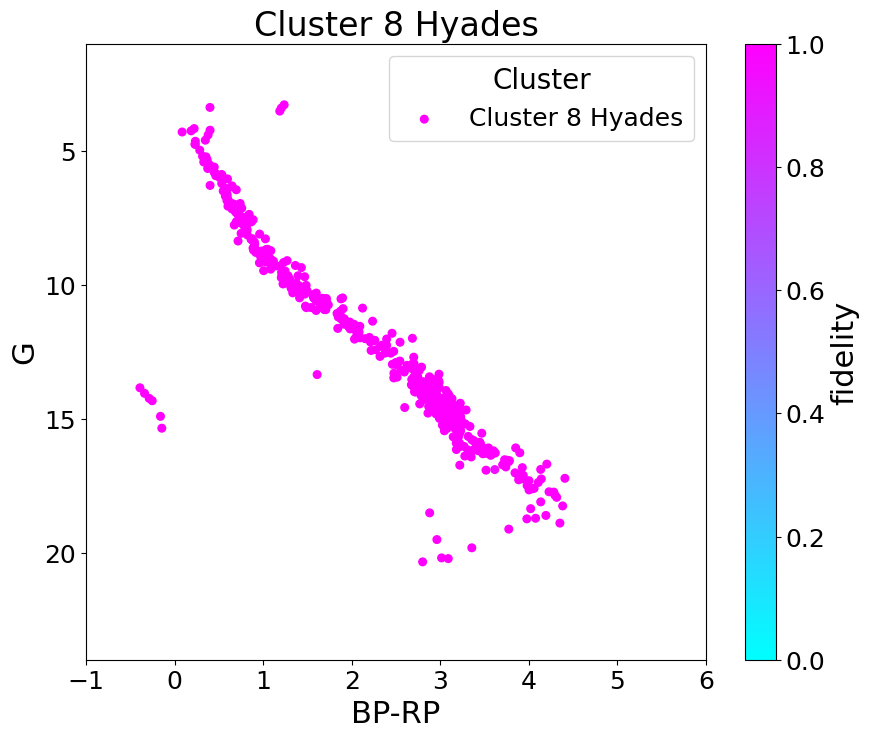

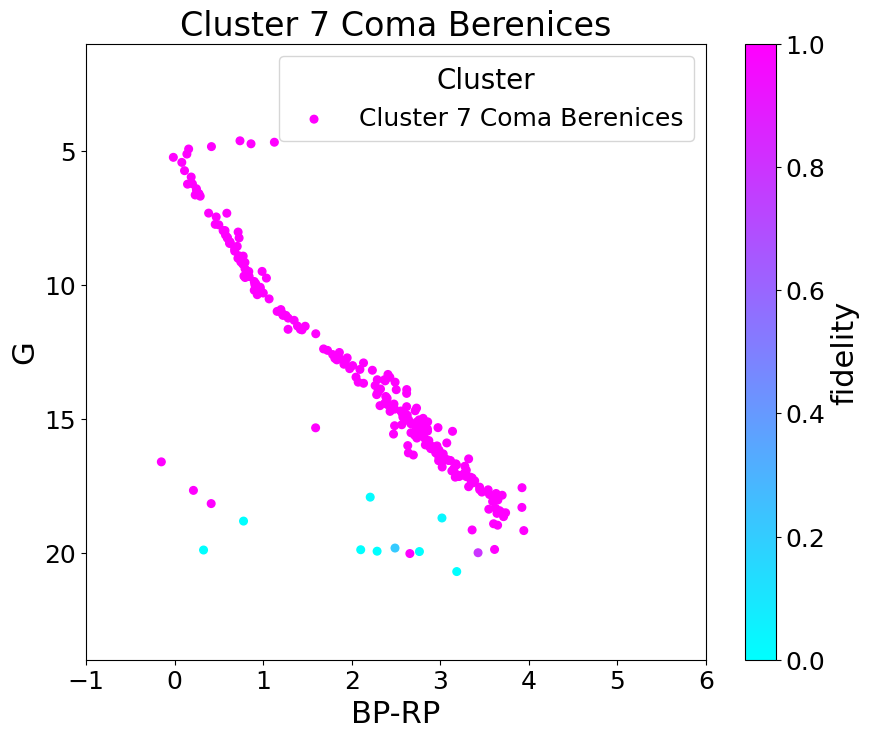

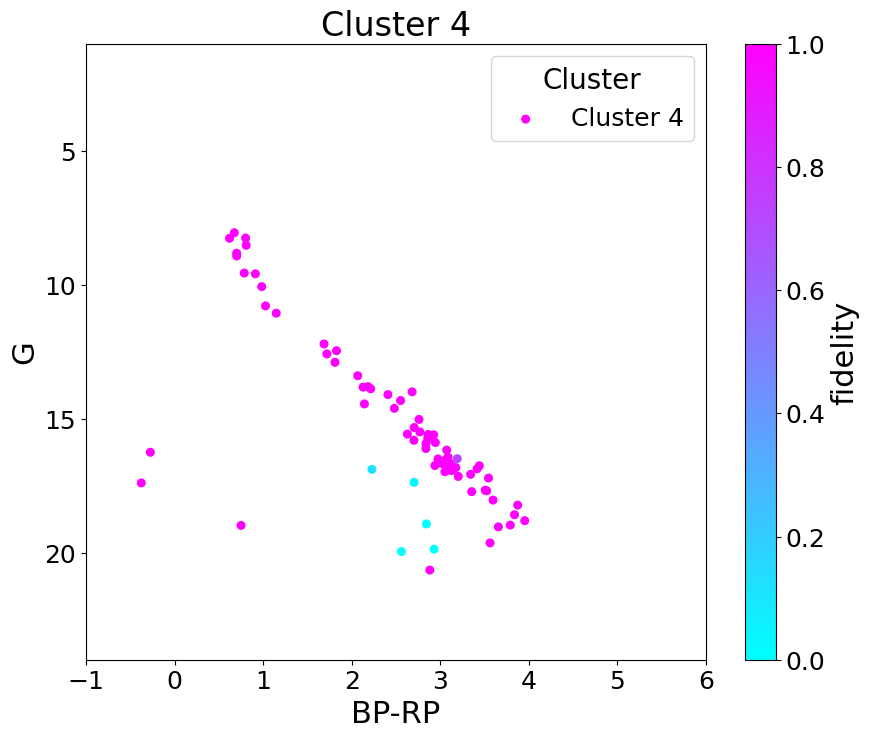

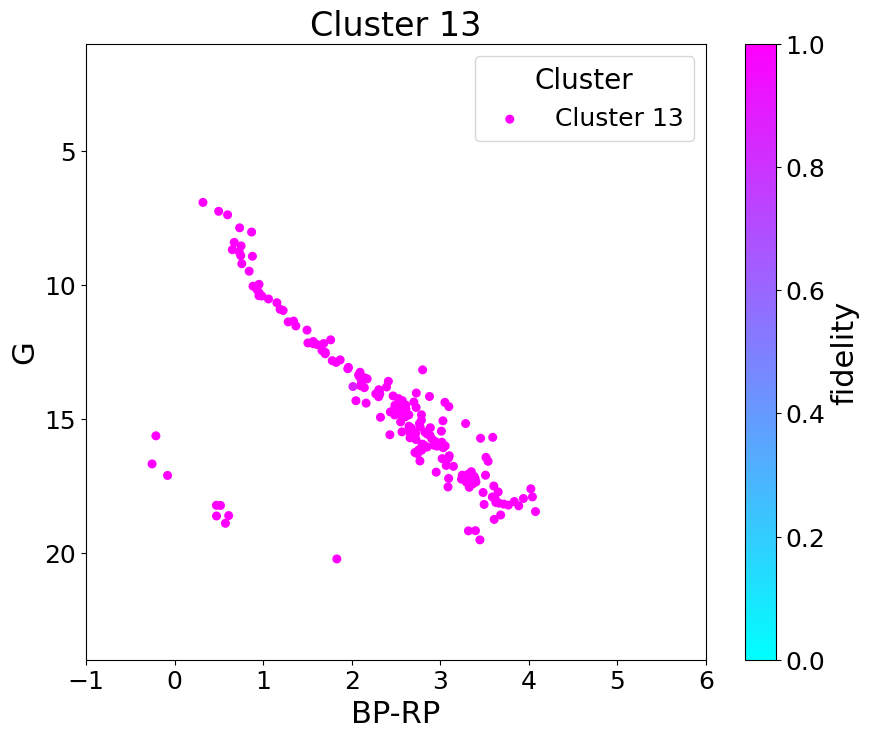

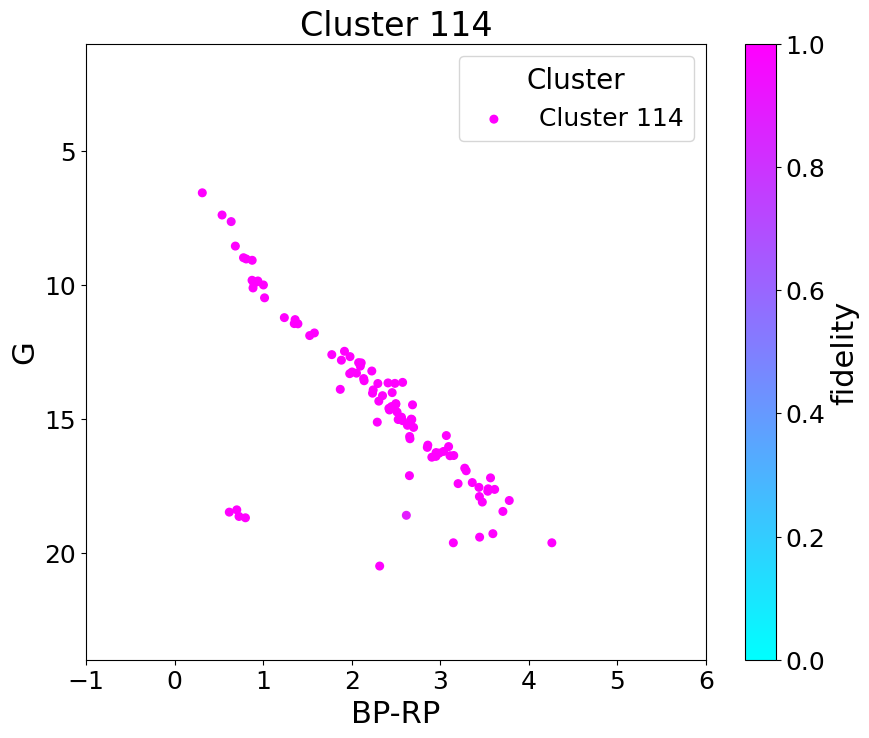

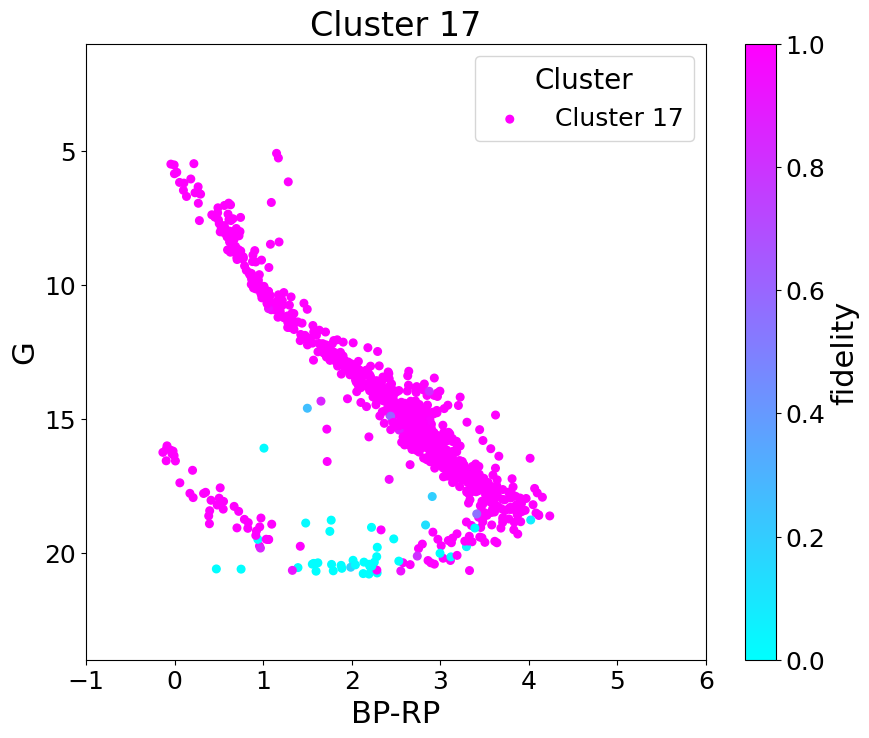

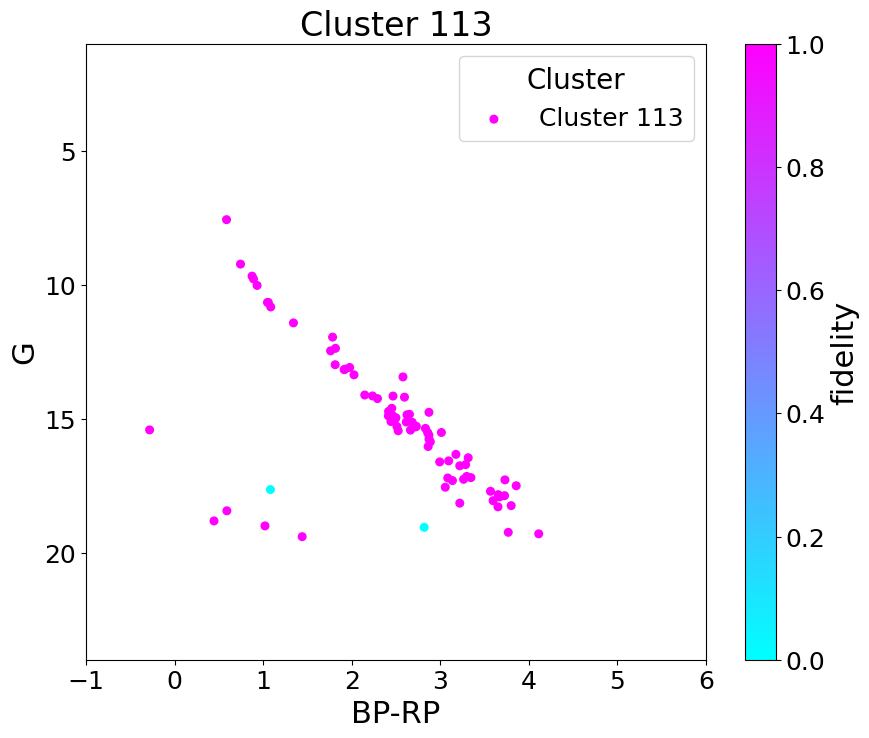

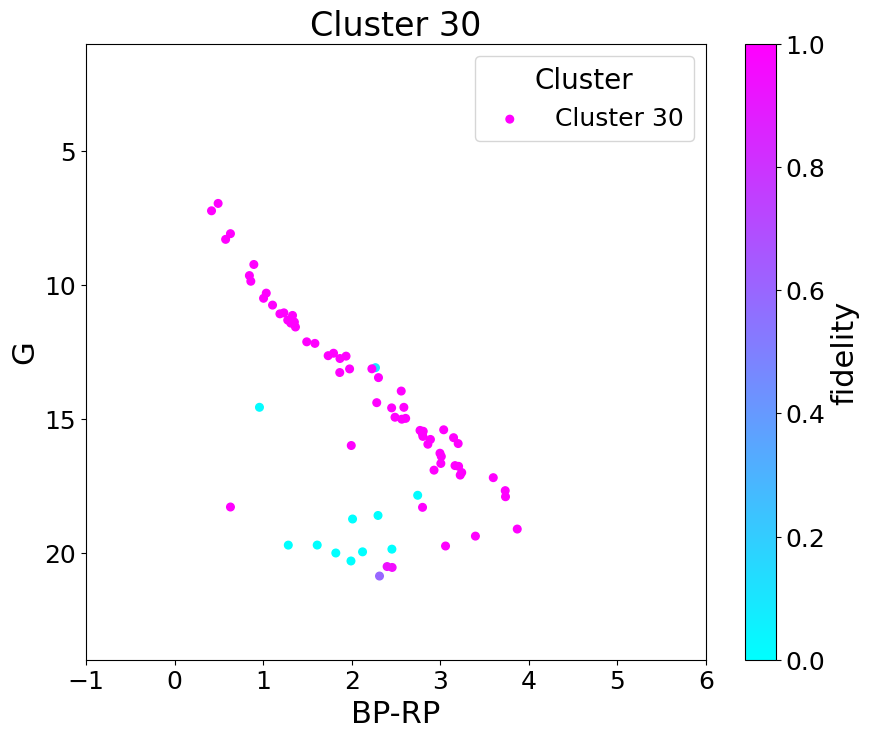

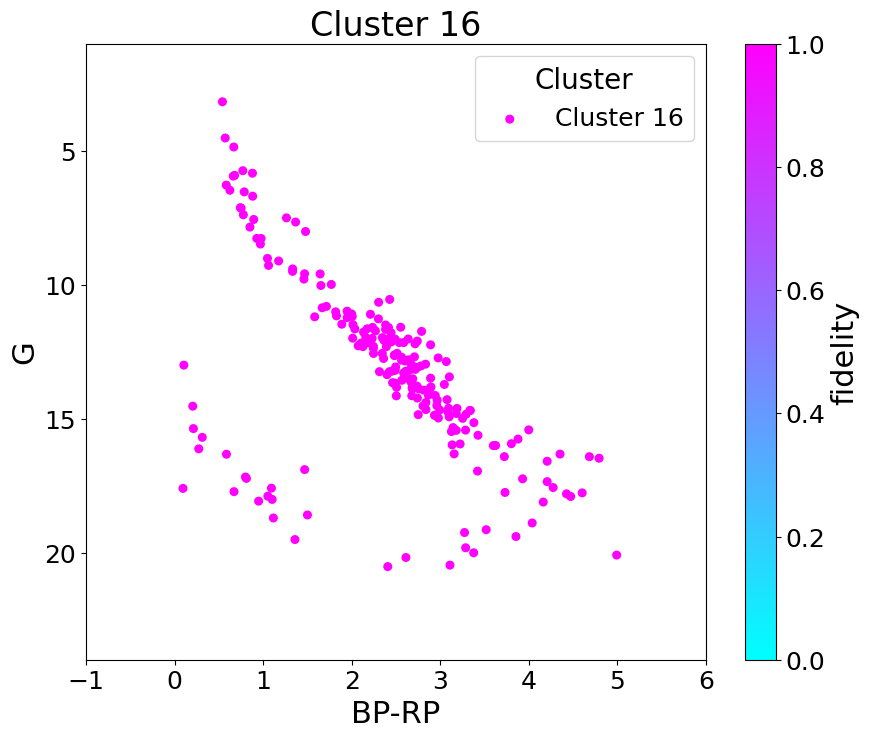

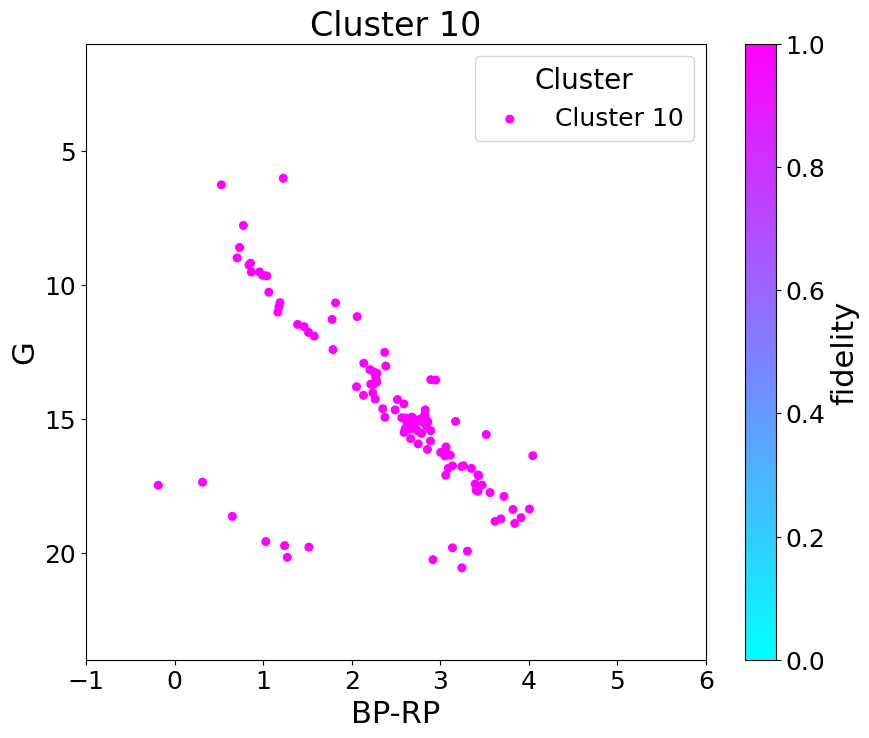

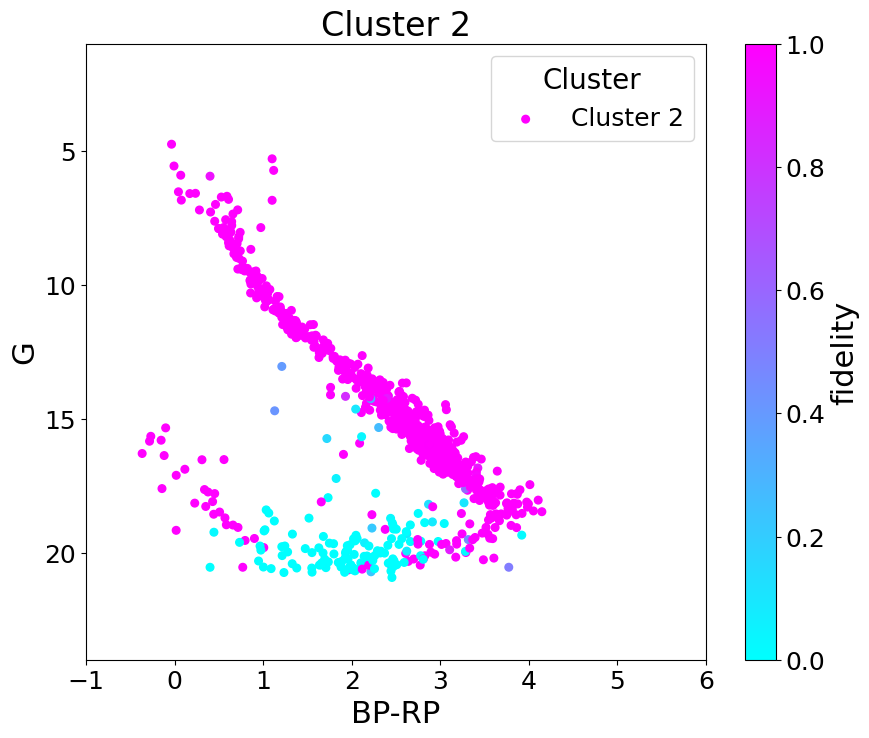

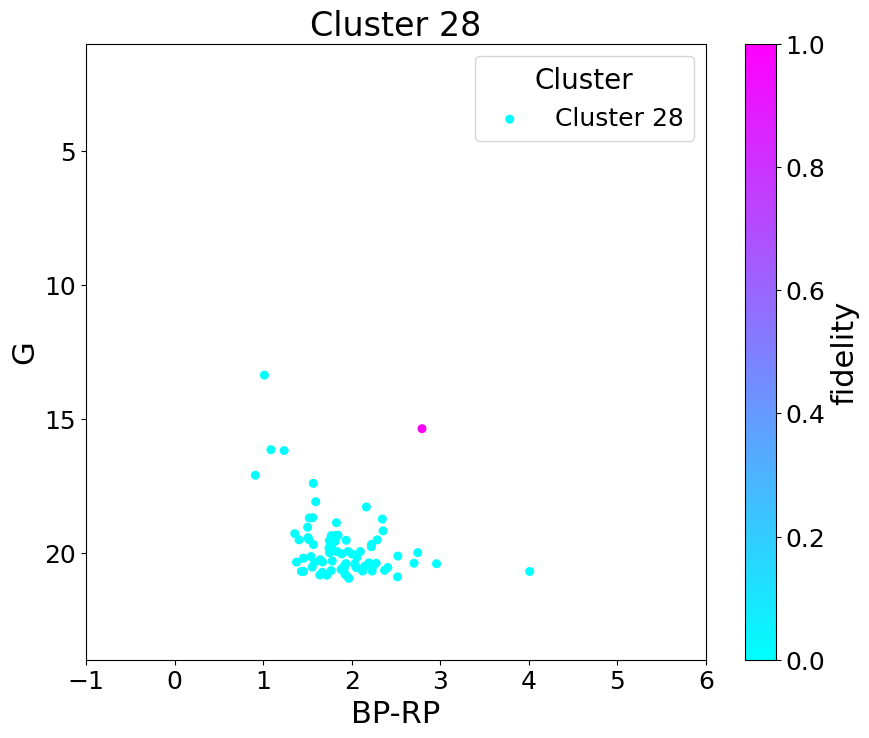

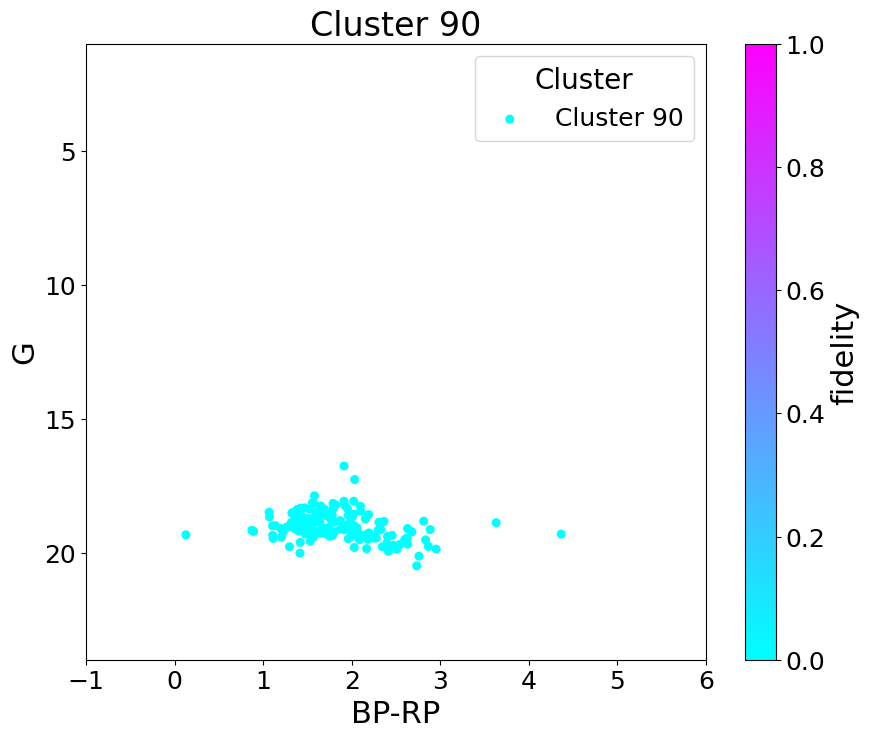

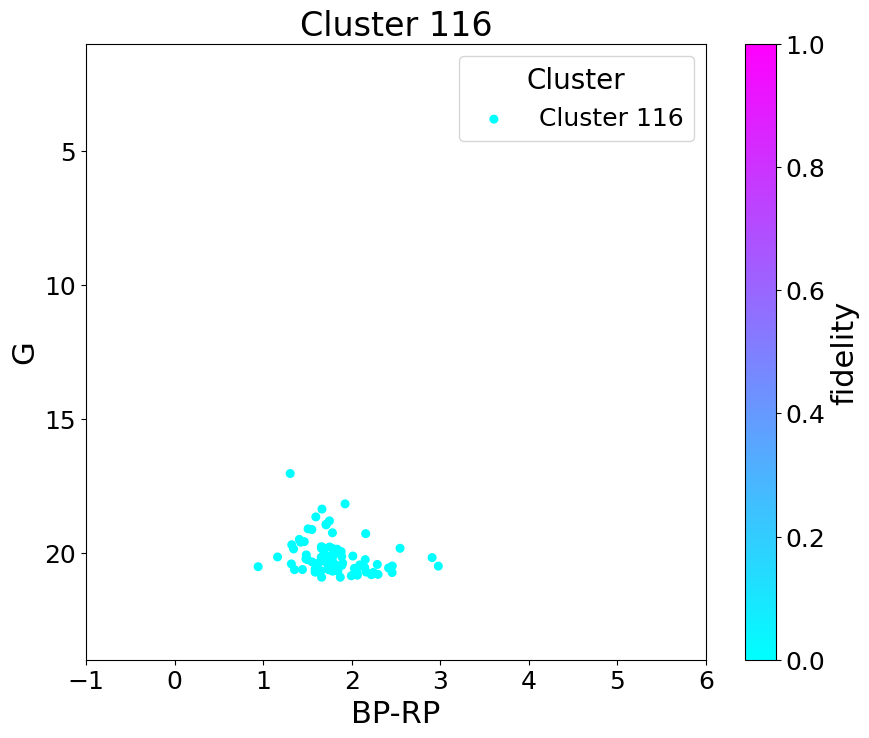

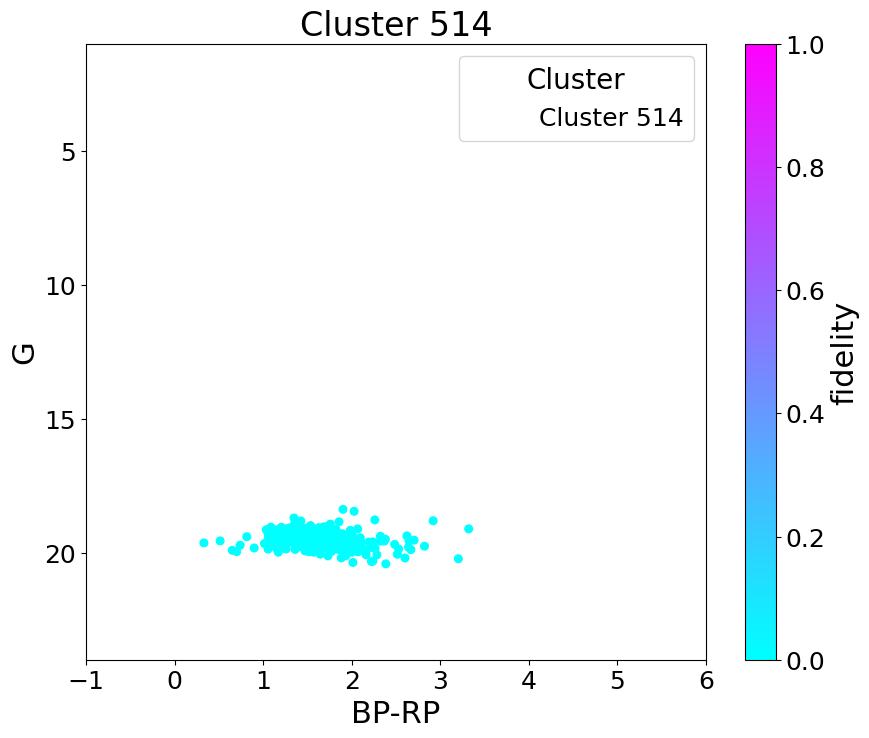

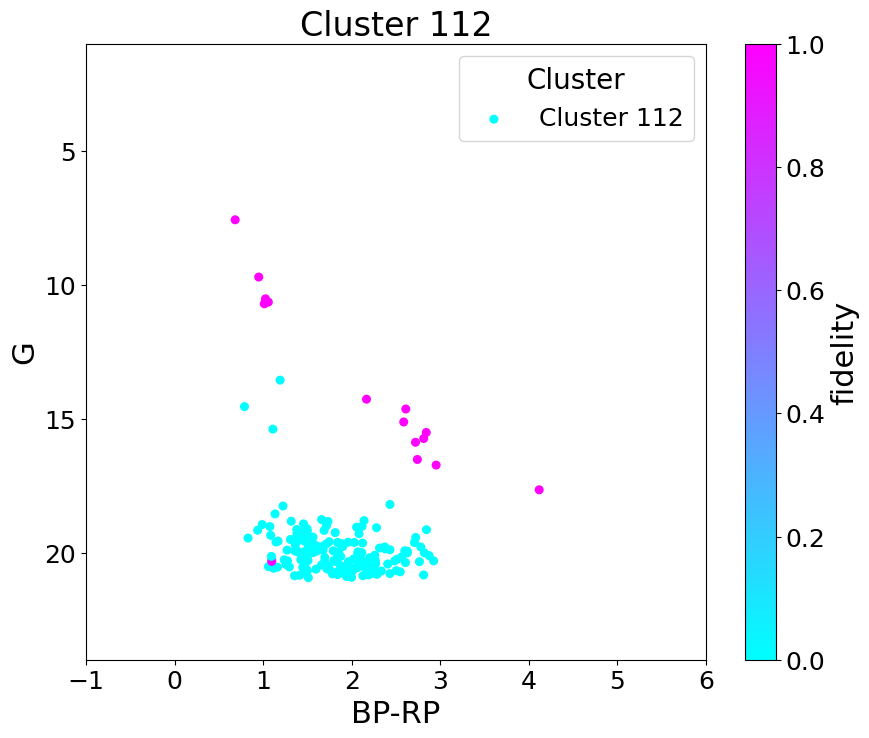

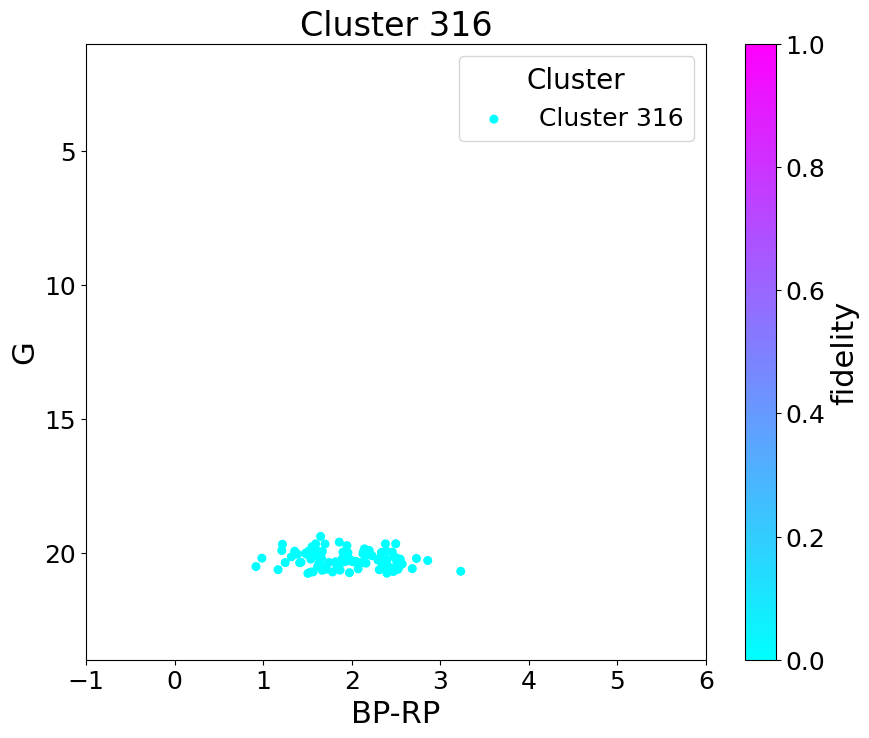

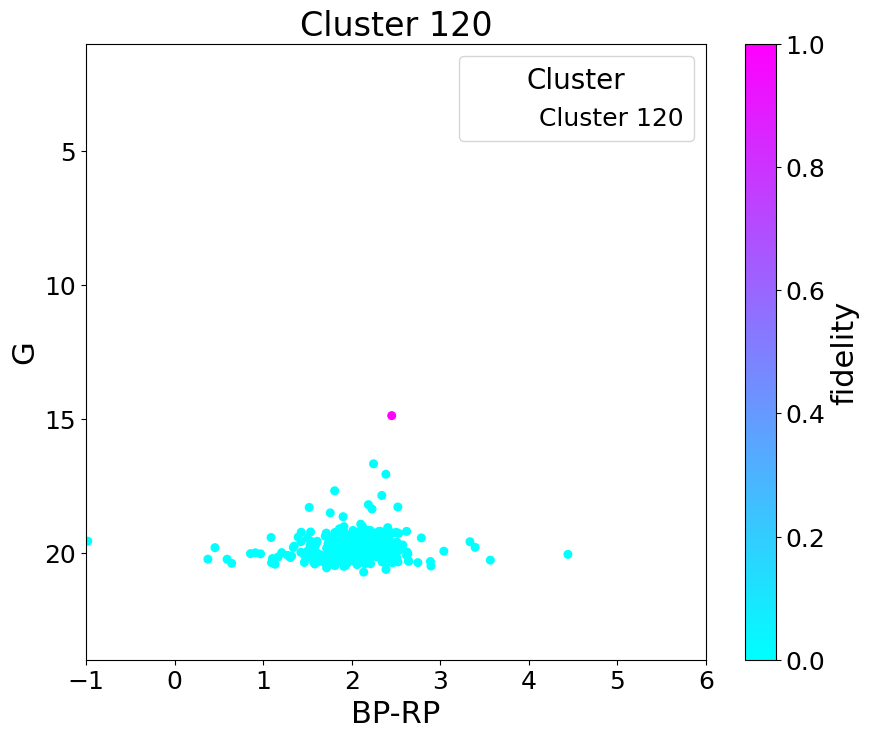

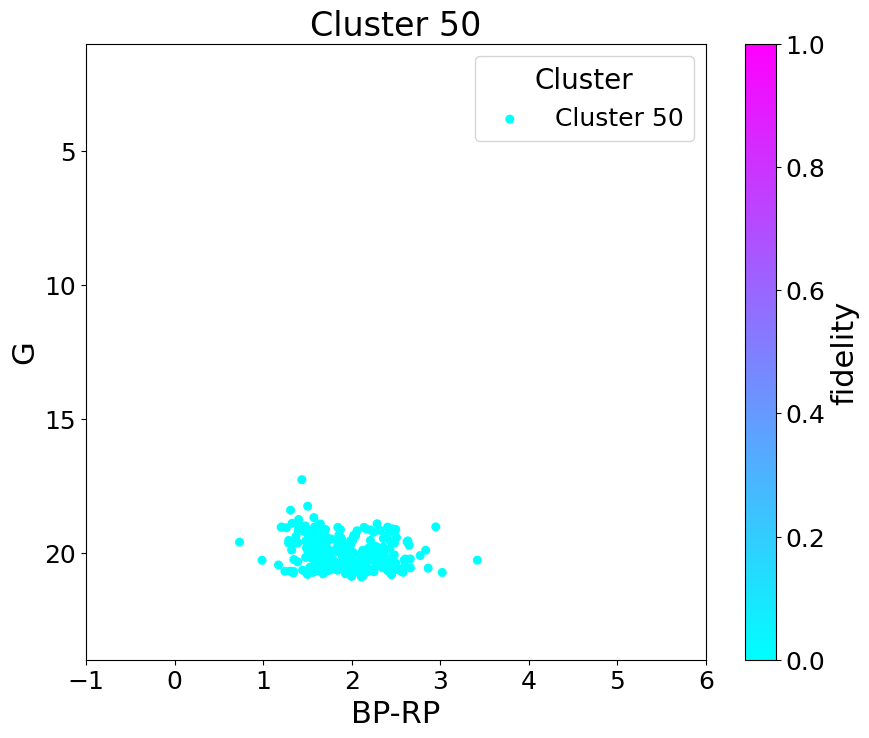

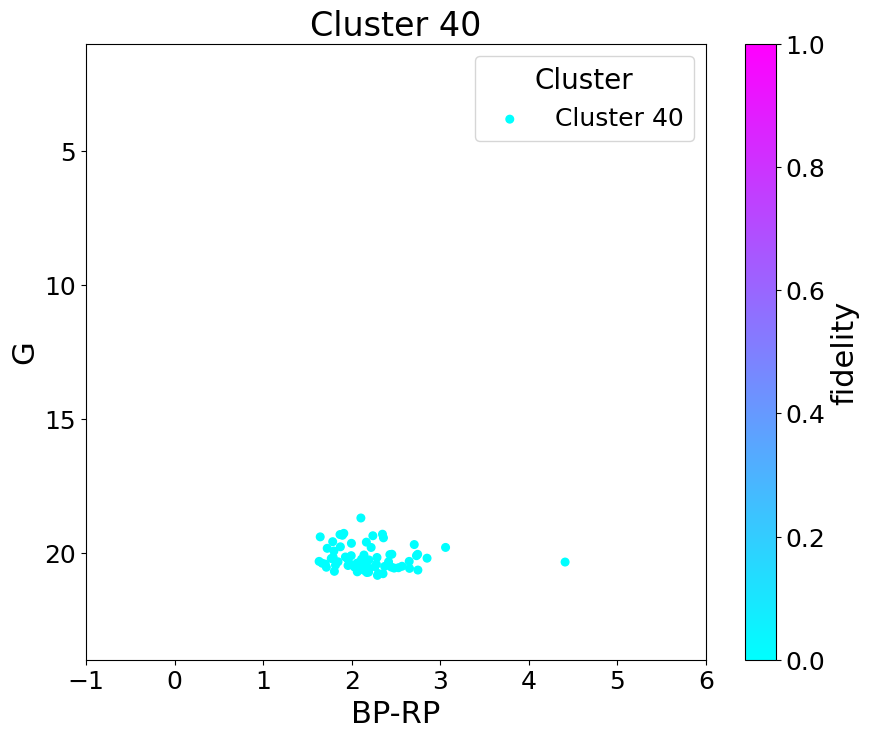

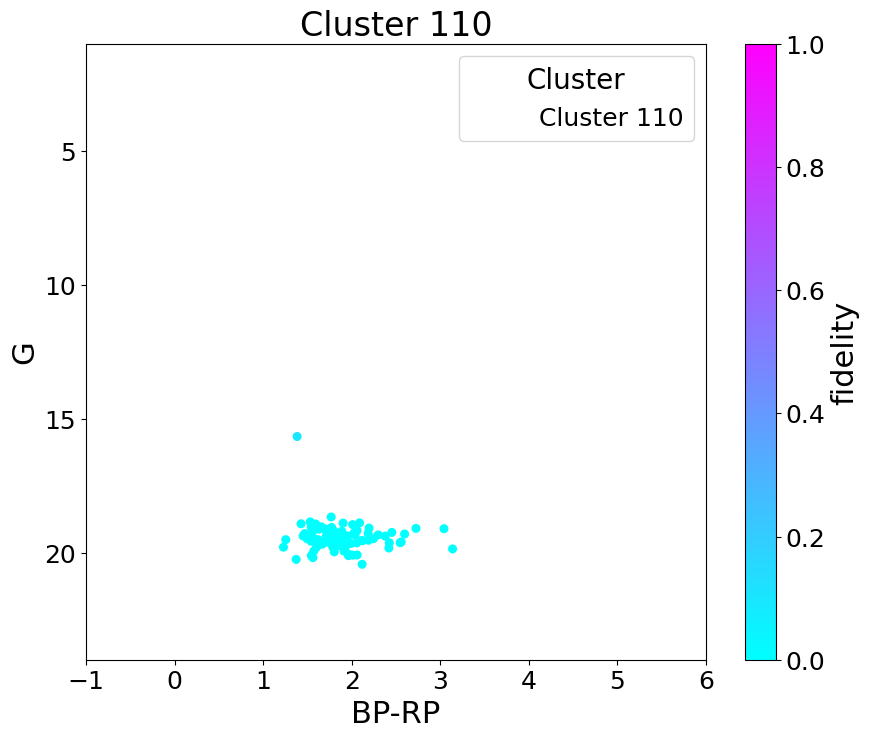

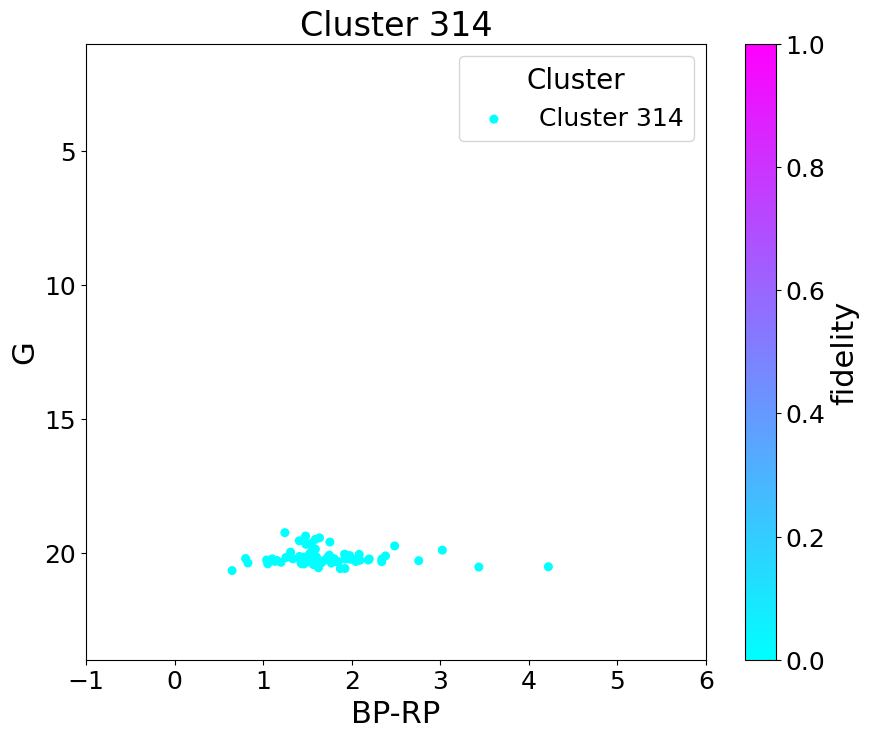

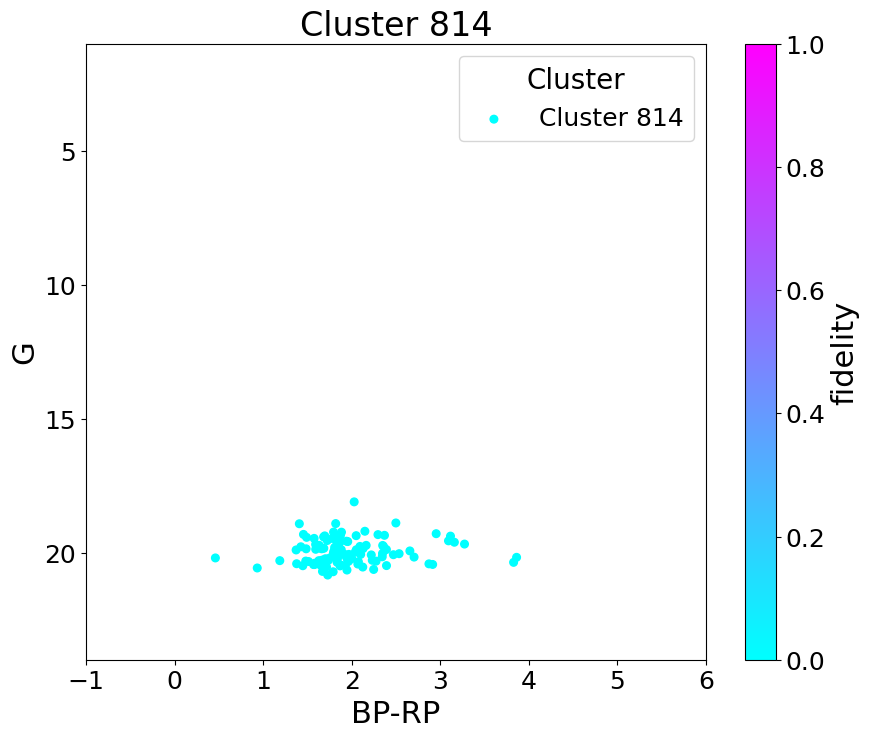

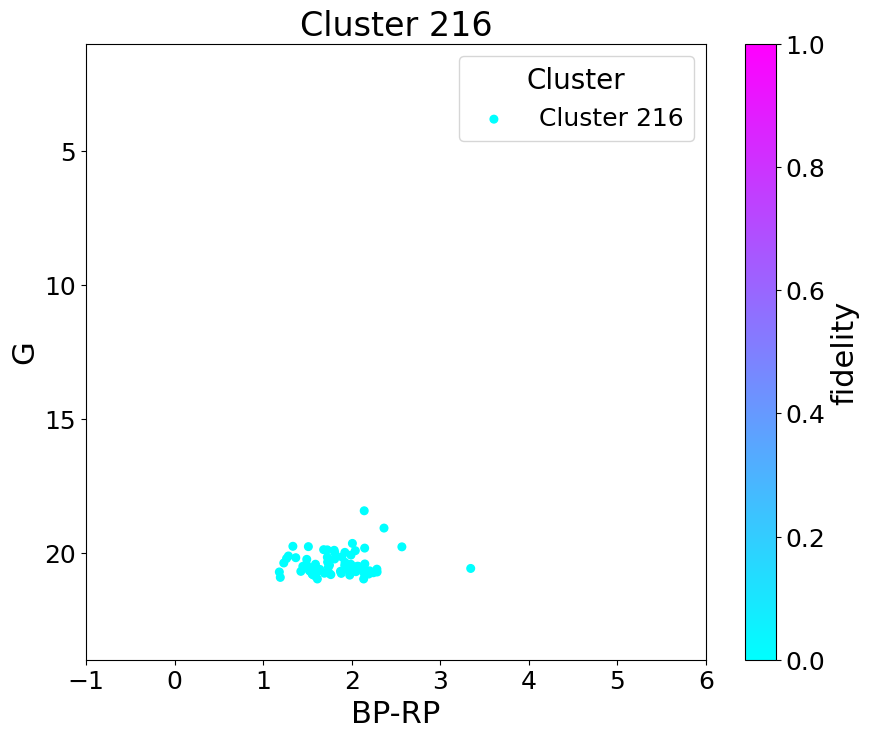

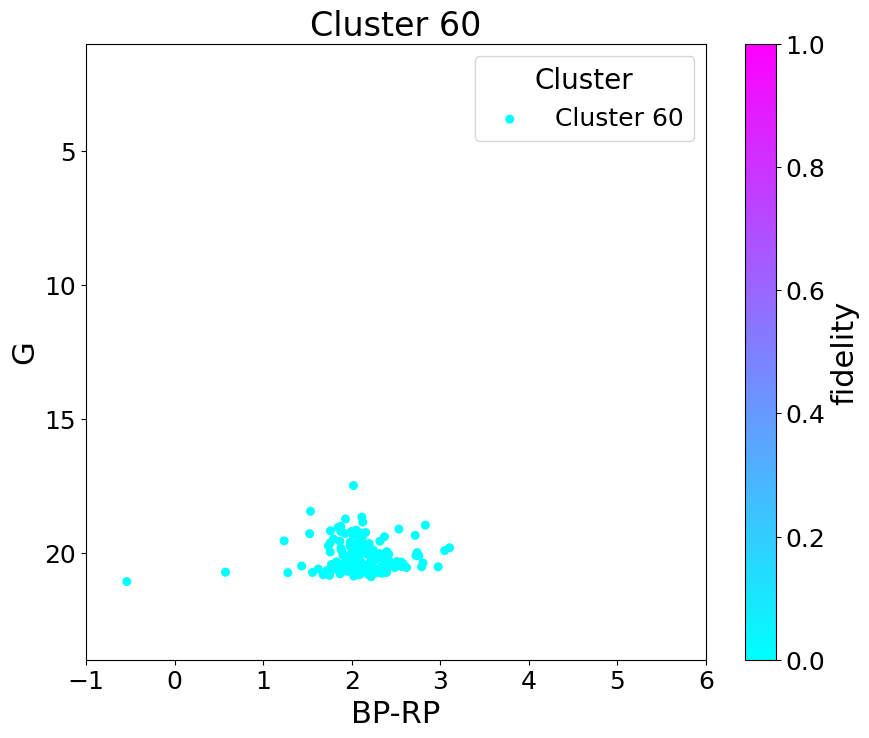

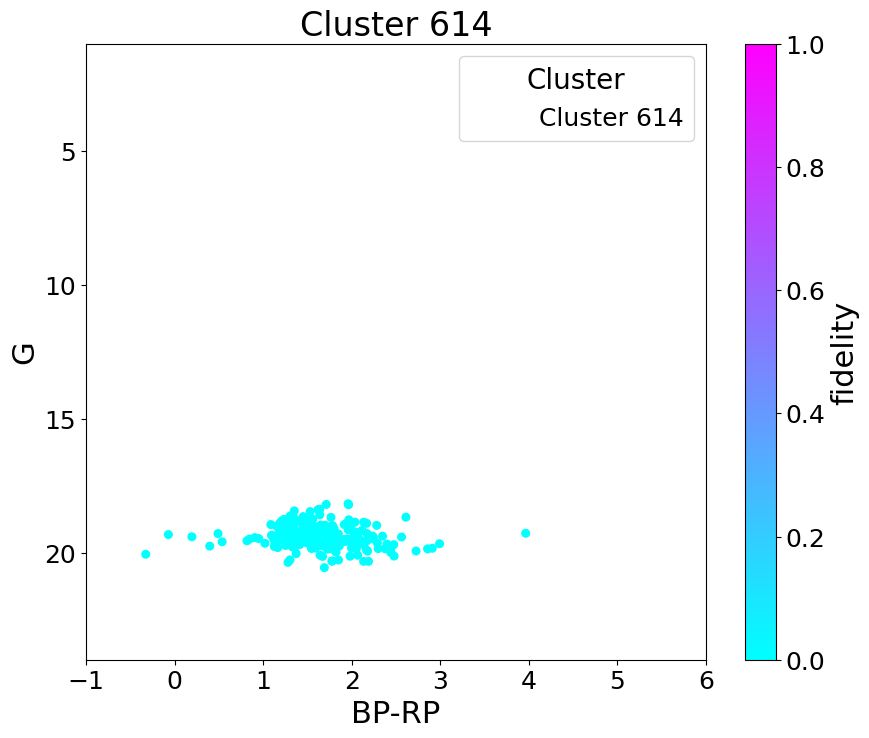

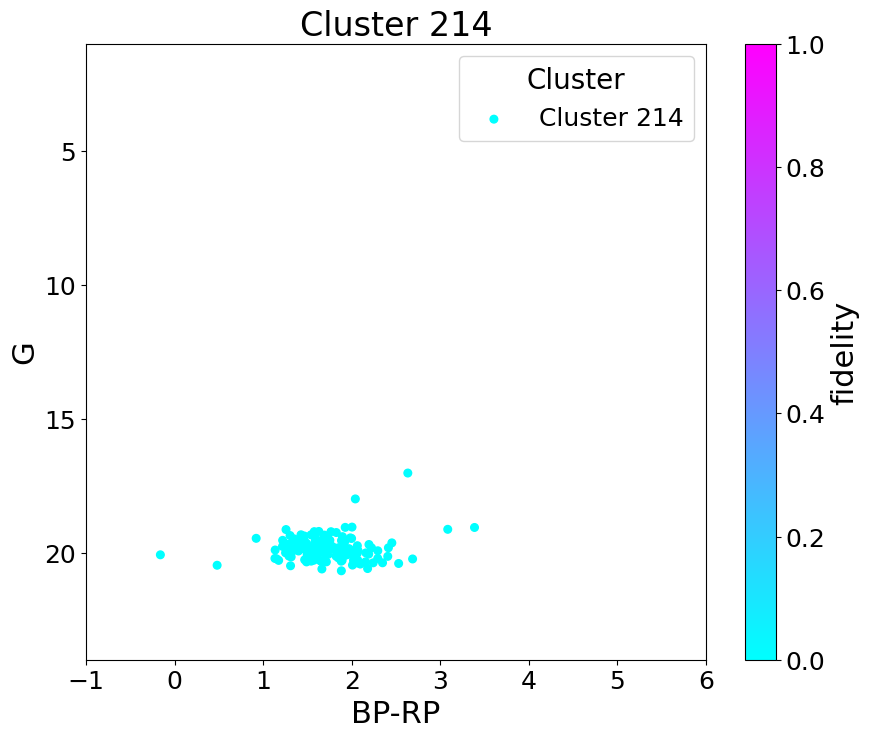

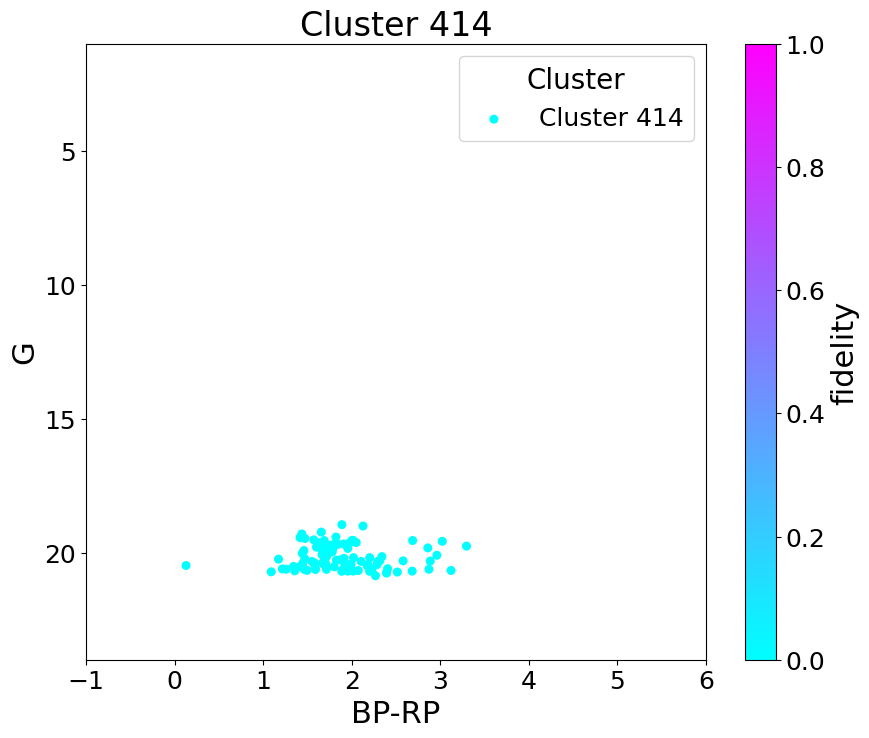

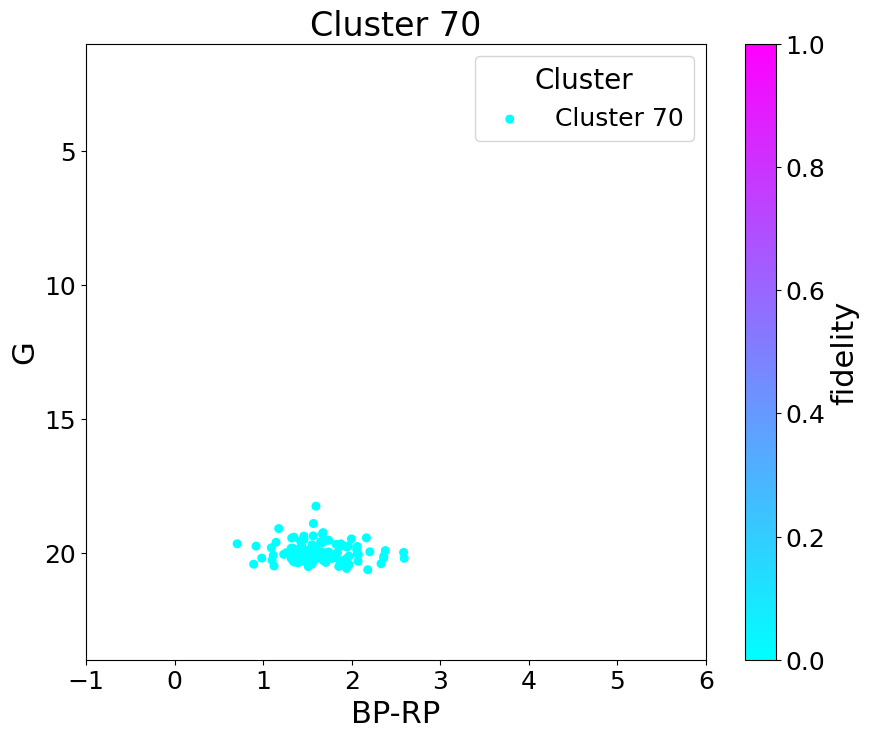

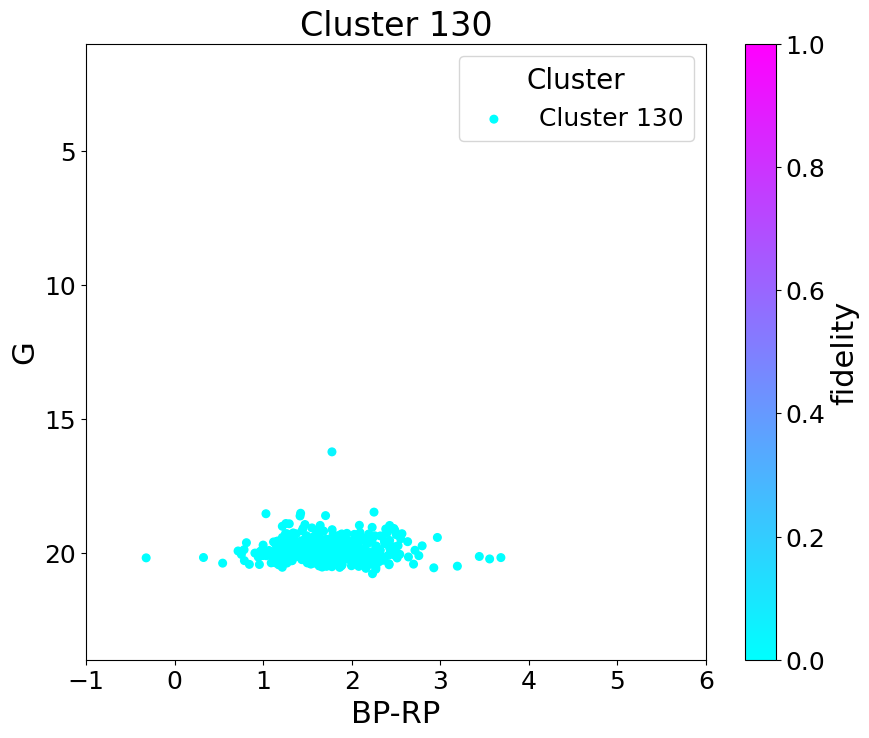

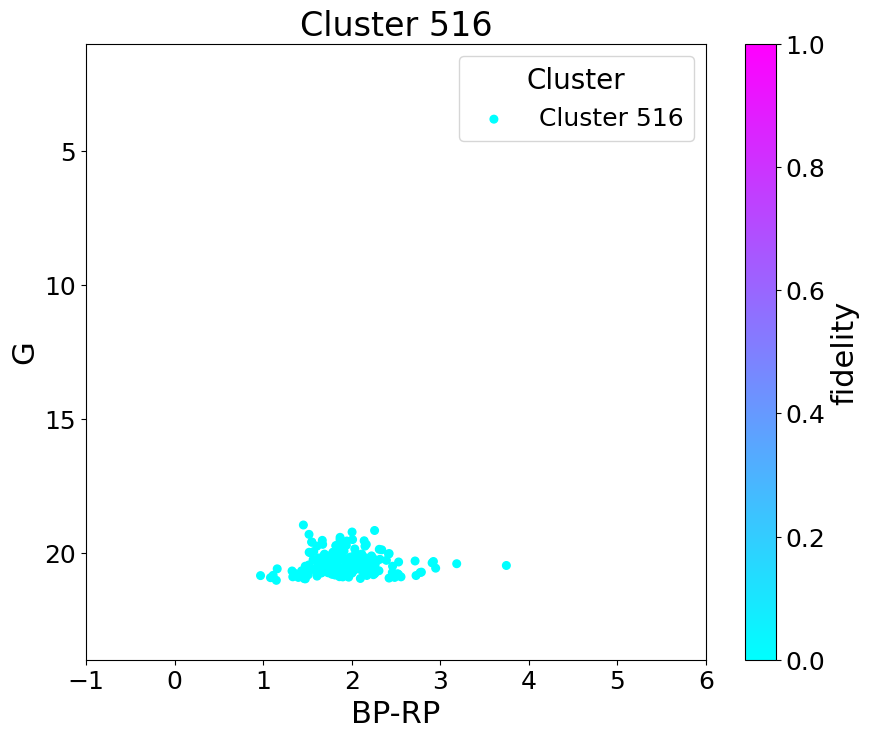

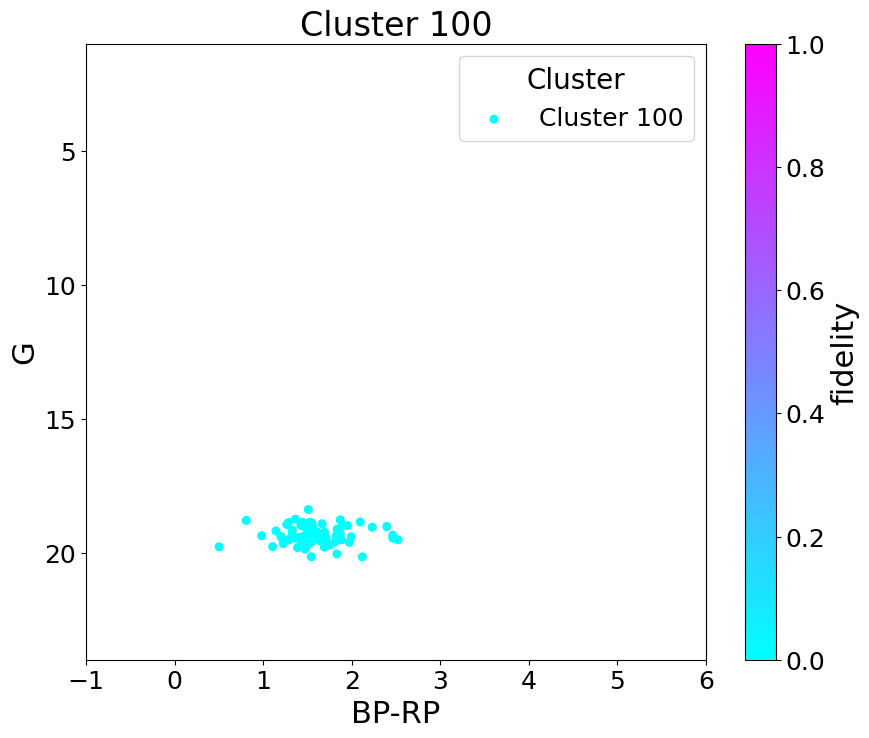

In [109]:
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(40)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]
    if cluster == 8:
        cluster  = "8 Hyades"
    if cluster == 7:
        cluster  = "7 Coma Berenices"
    # Dibujar ruido en negro con alfa fijo
    noise = dff[dff['cluster'] < 0]
    plt.figure(figsize = (10,8))
    # plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['fidelity_v2']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.cool

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('fidelity')

    plt.savefig(f"../data/ruta_imagenes_evolucion/diagrama_cluster_fidelity_{cluster}.png")
    plt.show()

In [110]:
# graficar en latitud y longitud galactiva

C:\Users\nicob\AppData\Local\Temp\ipykernel_15052\2752474401.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  sc = plt.scatter(subset['bp_rp'], subset['abs'],


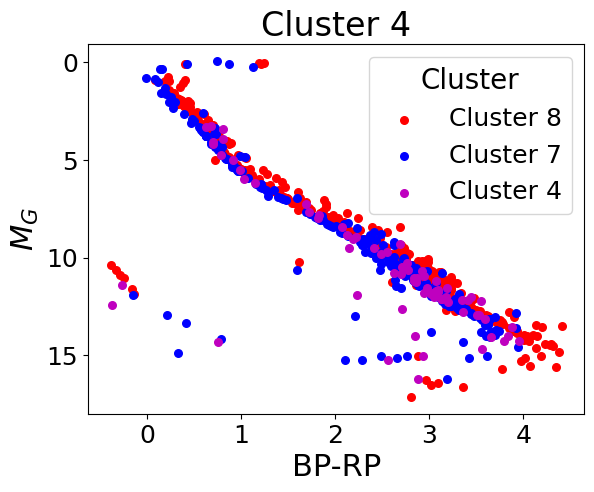

In [111]:
dic_color = dict(zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values,["red","blue","m"]))
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(3)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['abs'],
                     c=dic_color[cluster],
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel(r'$M_G$')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.gca().invert_yaxis()
plt.show()

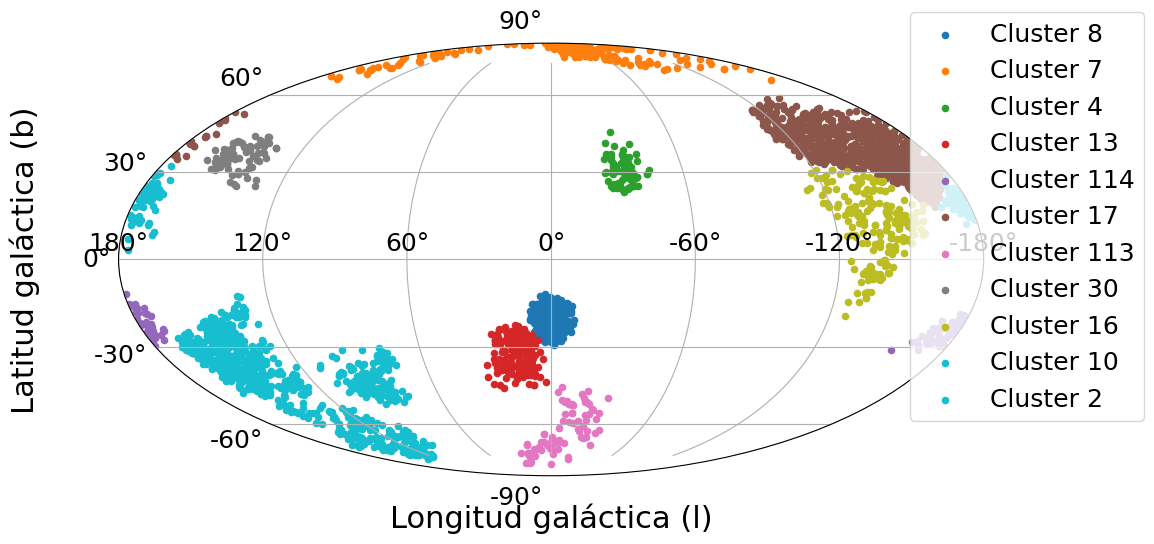

In [112]:
# Crear figura Mollweide
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')

# Graficar por cada cluster
clusters = silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(11)['cluster'].values
colors = plt.cm.tab10(np.linspace(0, 1, len(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(11)['cluster'].values)))  # Paleta de colores
  # Paleta de colores

for cluster, color in zip(silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(11)['cluster'].values, colors):
    subset = dff[dff['cluster'] == cluster].reset_index(drop=True)
    ax.scatter(subset['l_rad'], subset['b_rad'], s=20, alpha=1, label=f'Cluster {cluster}', color=color)

# Etiquetas y rejilla
ax.set_xticks(np.radians(np.arange(-180, 181, 60)))
ax.set_yticks(np.radians(np.arange(-90, 91, 30)))
ax.set_xticklabels(['180°', '120°', '60°', '0°', '-60°', '-120°', '-180°'])
ax.set_yticklabels(['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°'])
ax.grid(True)
ax.set_xlabel('Longitud galáctica (l)', labelpad=20)
ax.set_ylabel('Latitud galáctica (b)', labelpad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()

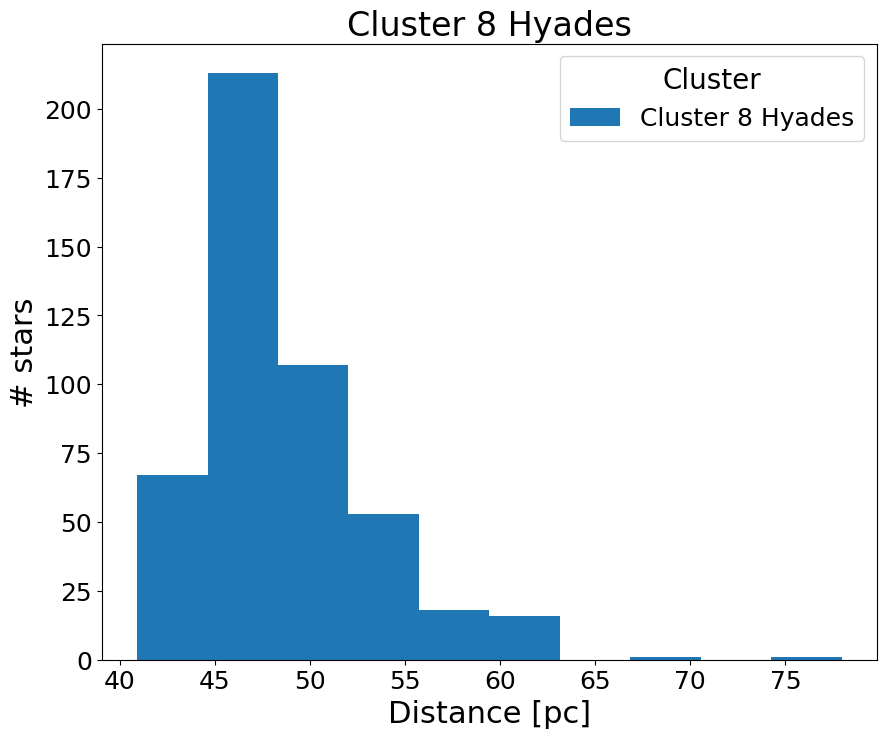

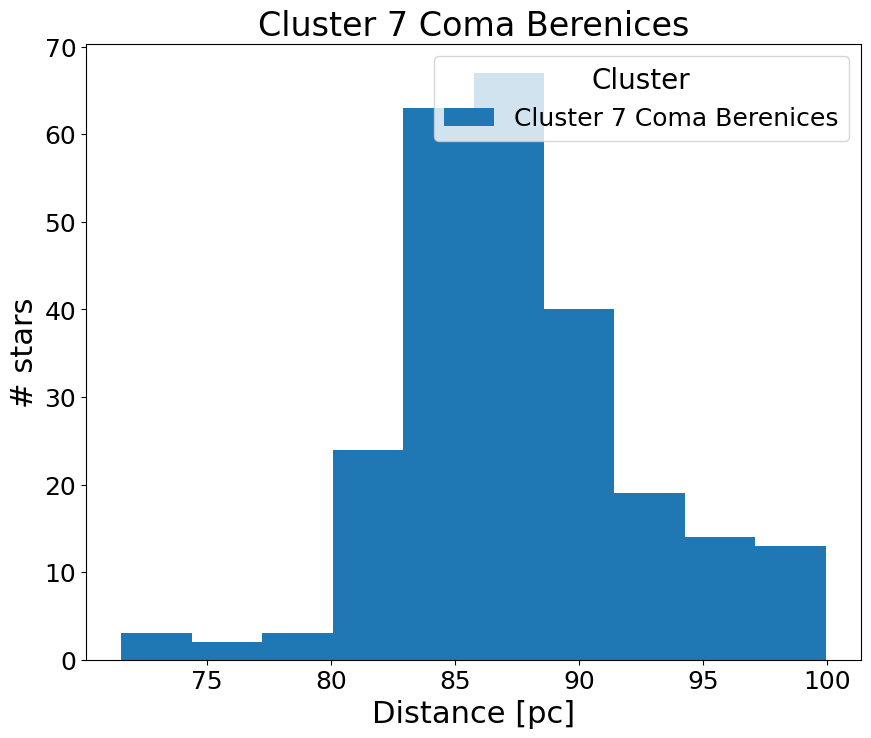

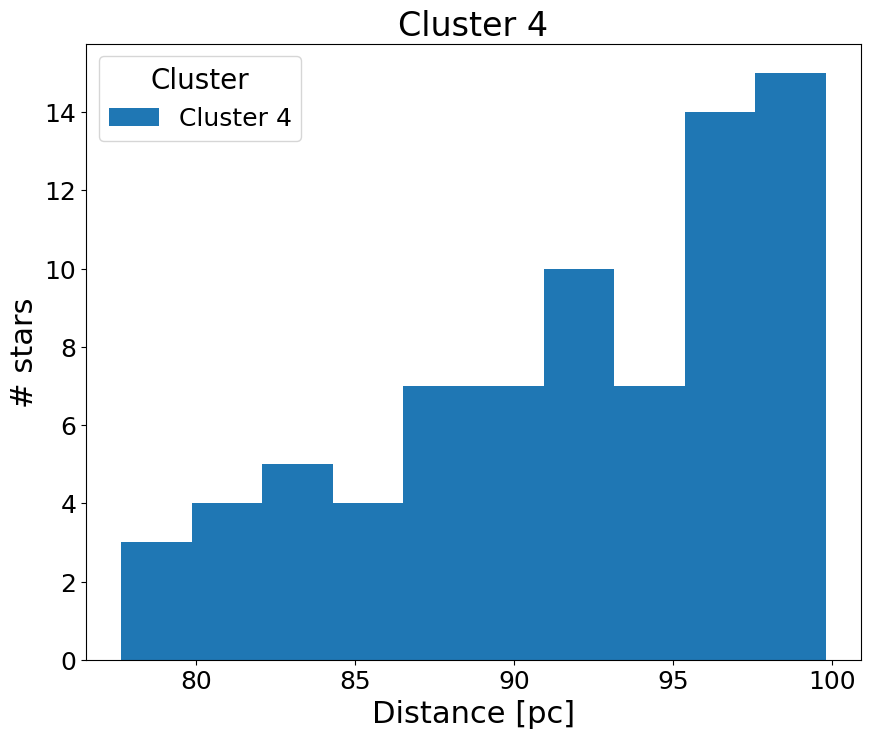

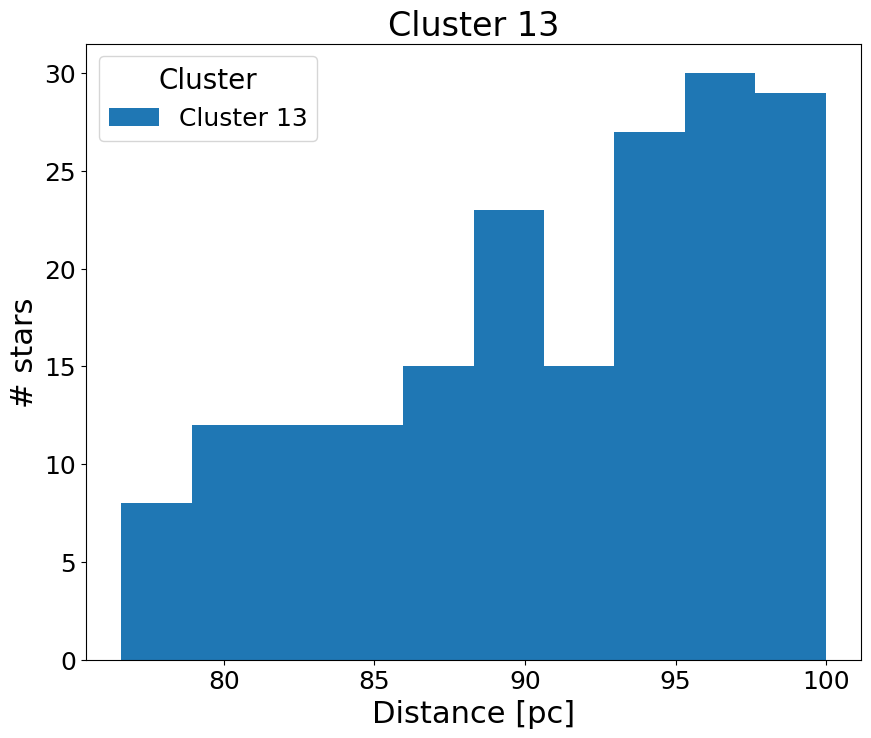

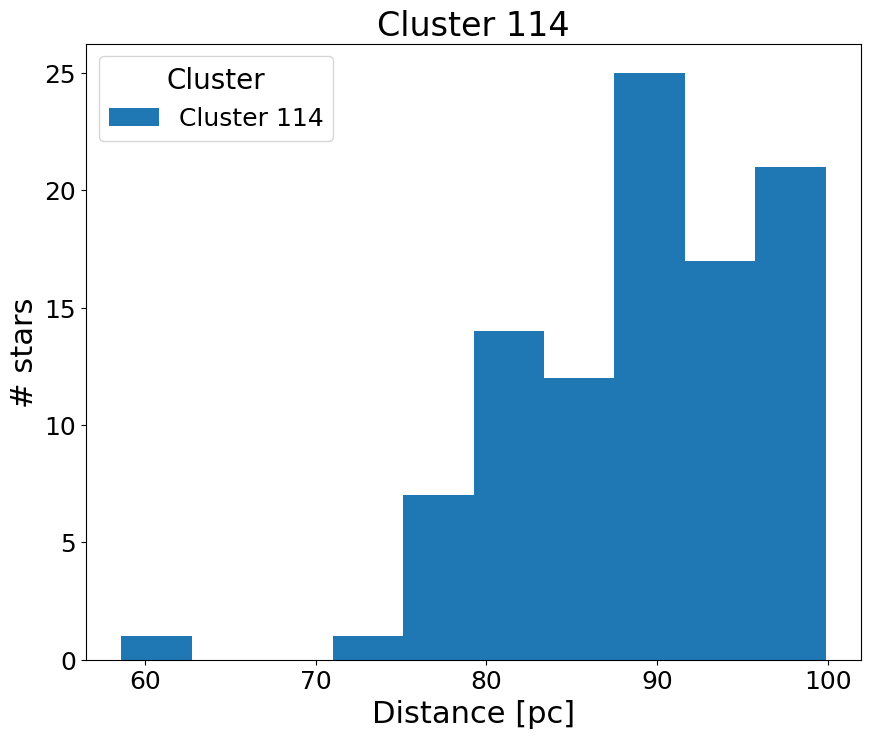

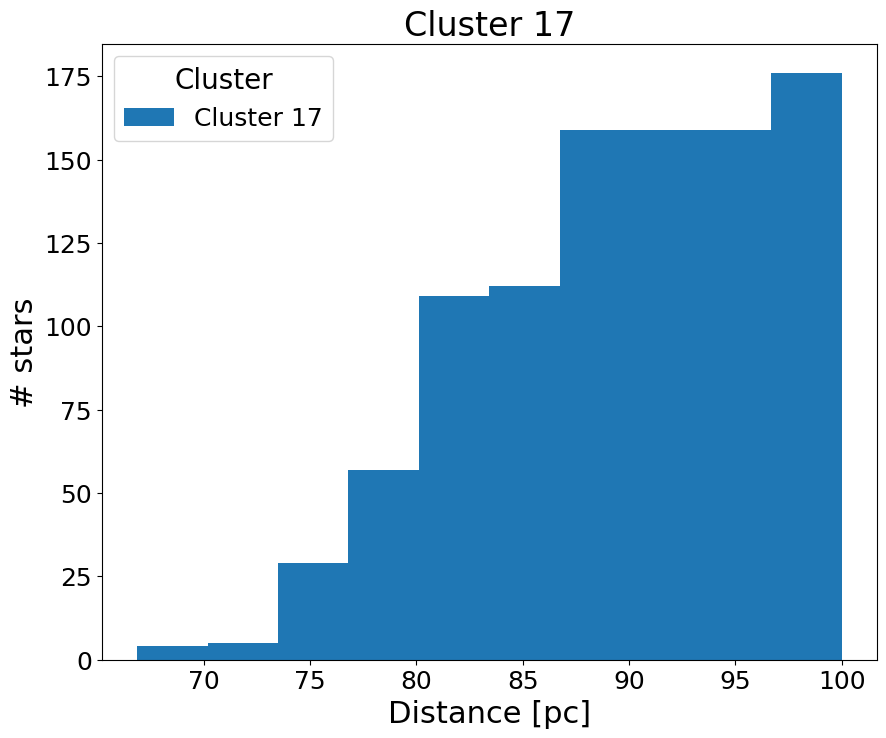

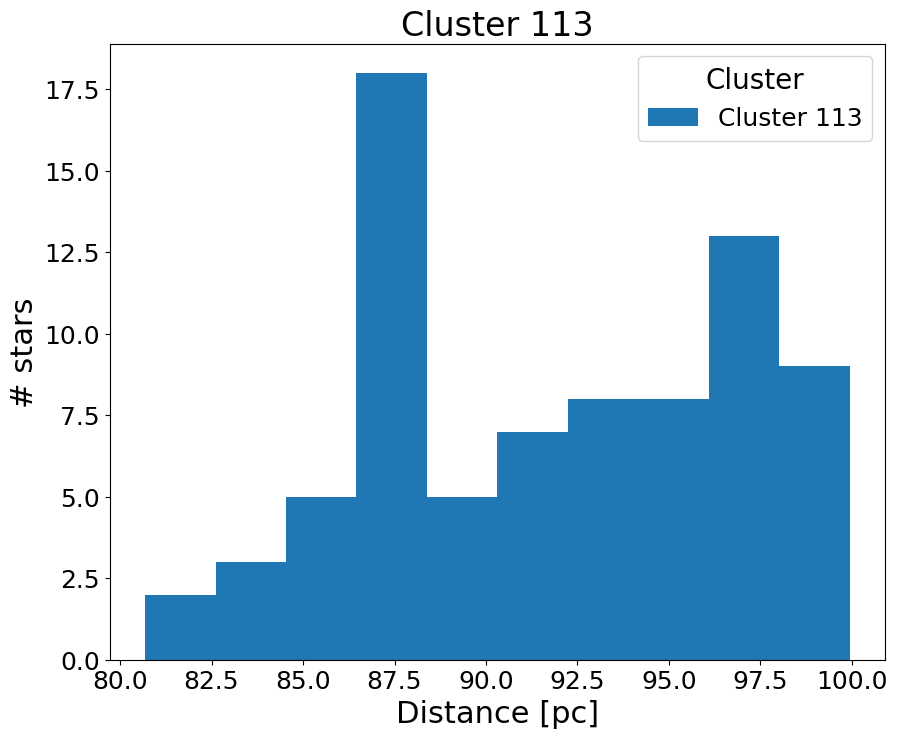

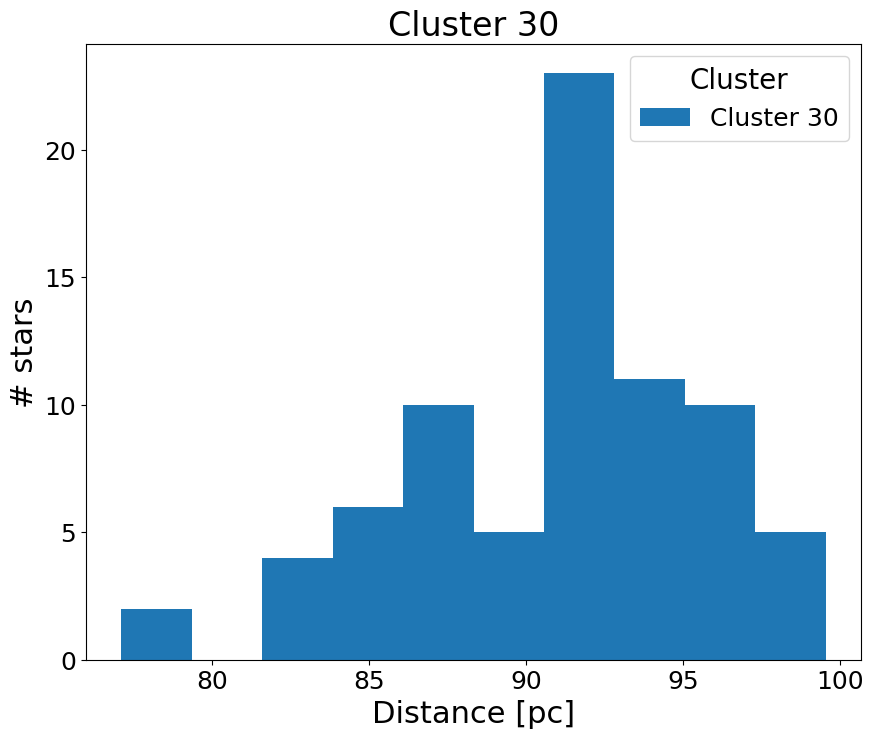

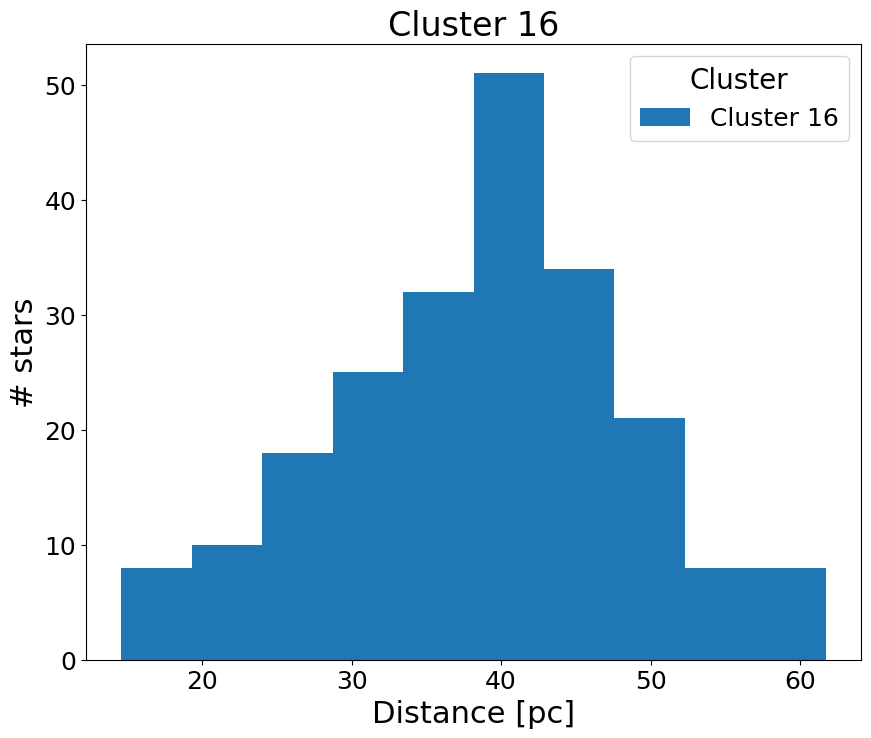

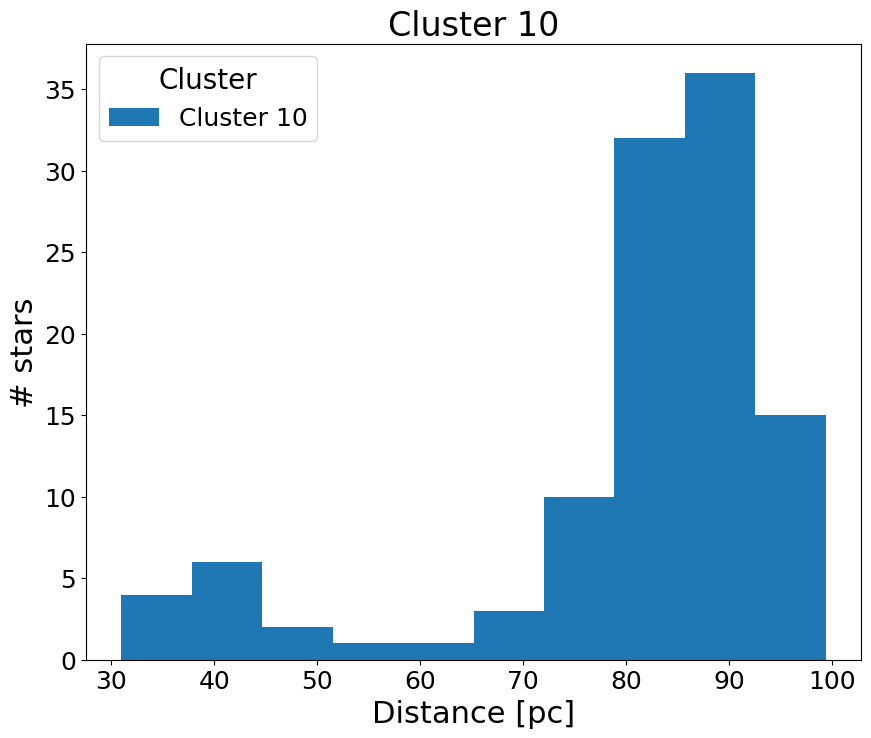

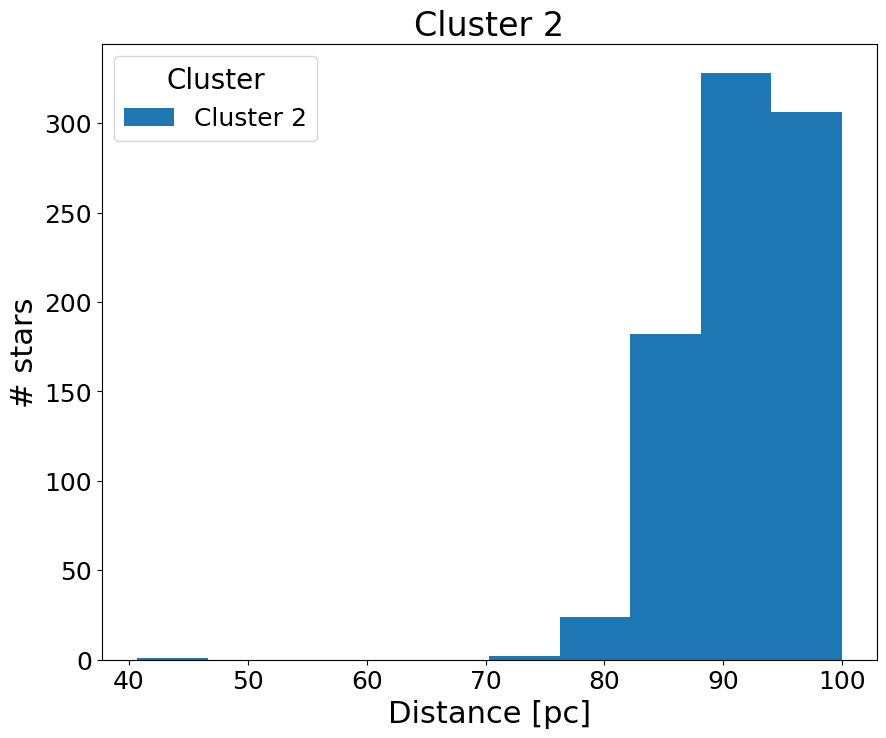

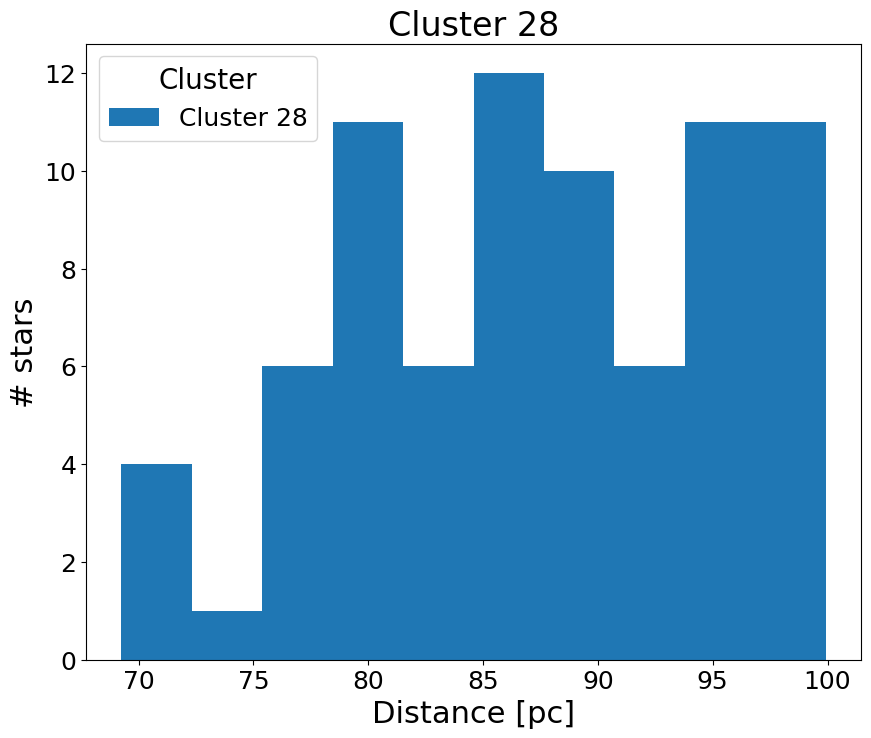

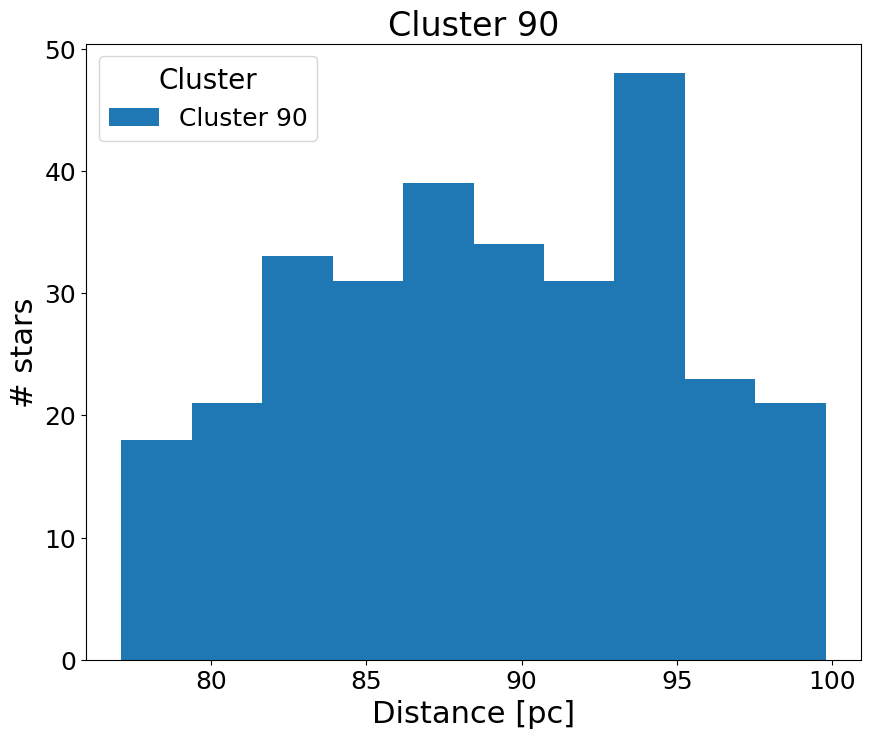

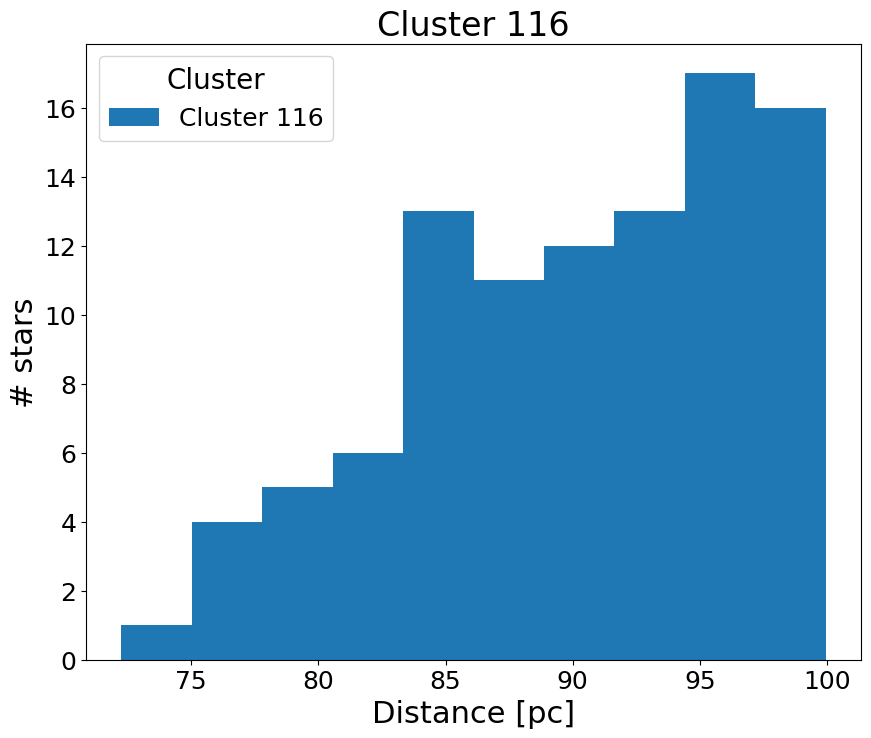

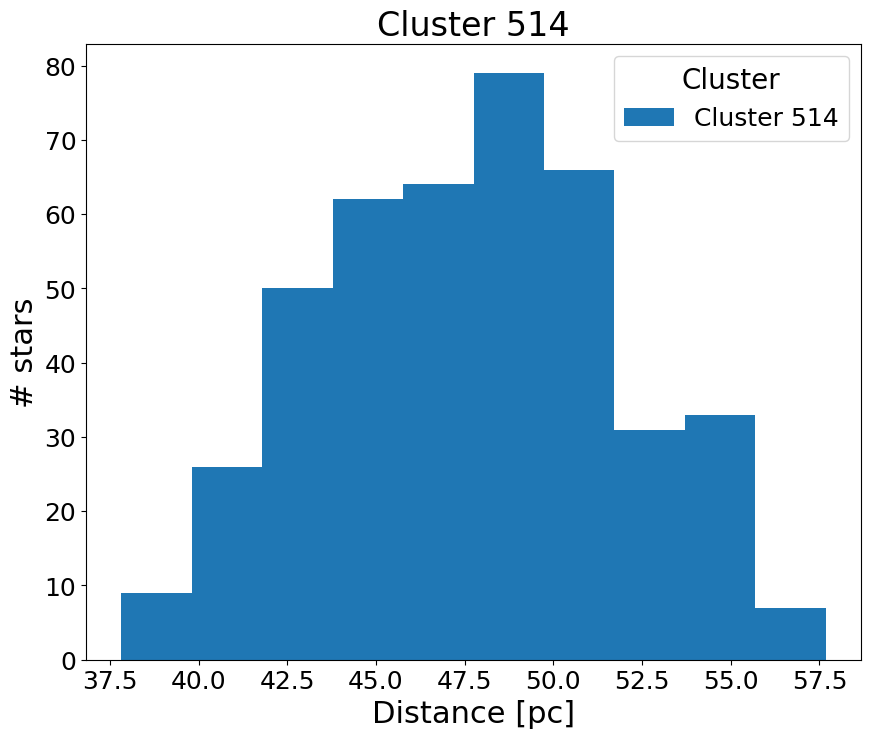

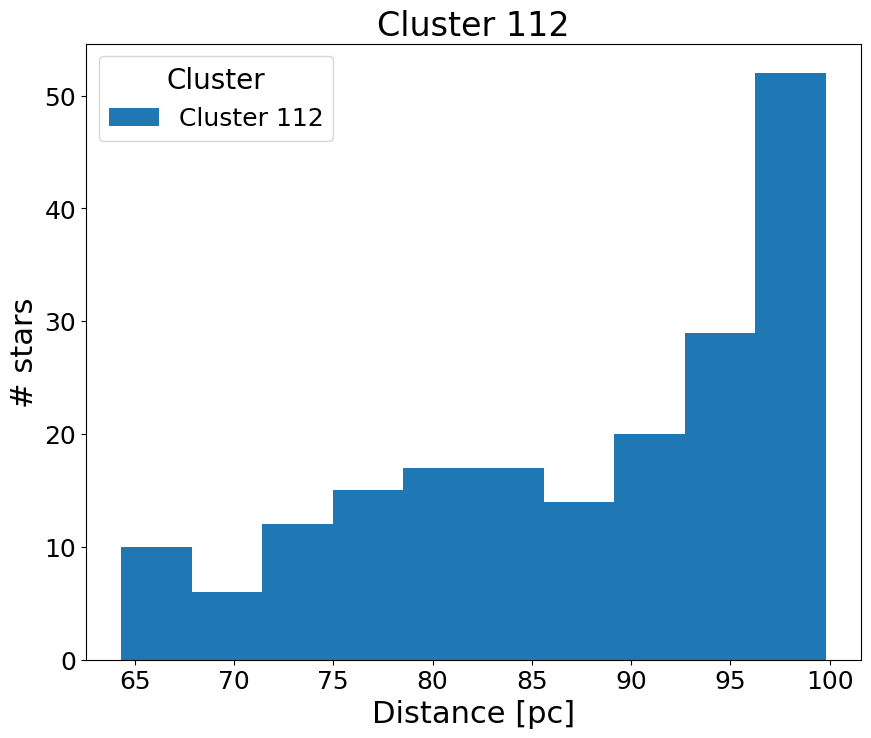

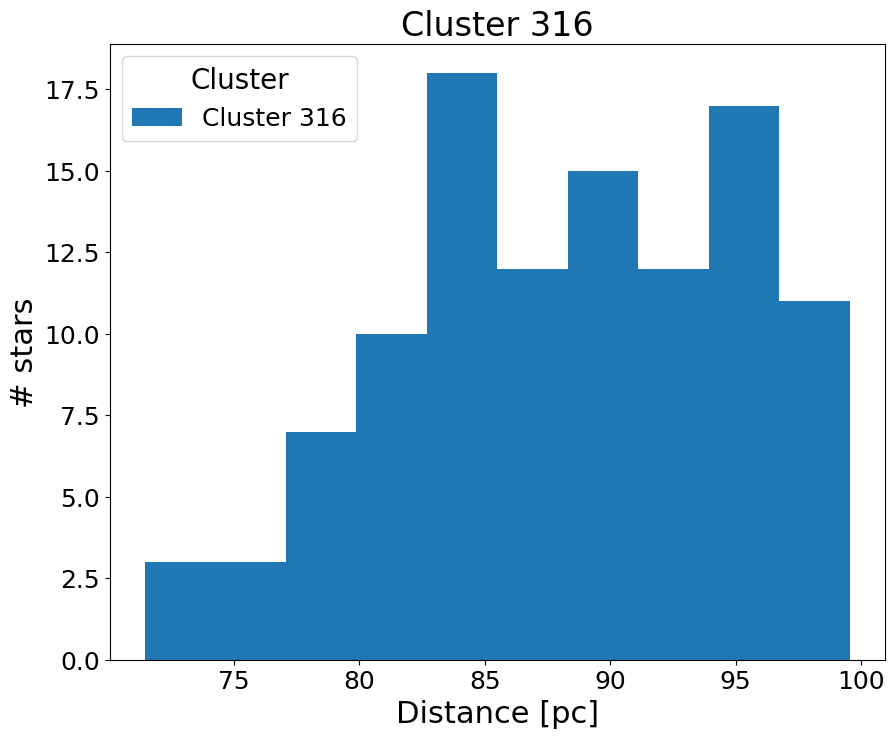

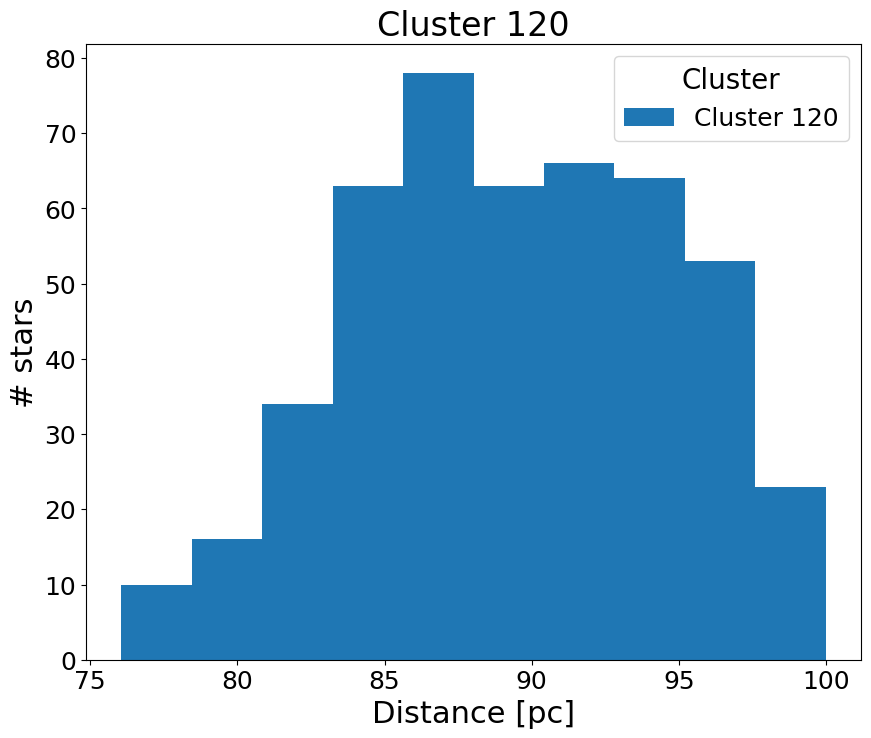

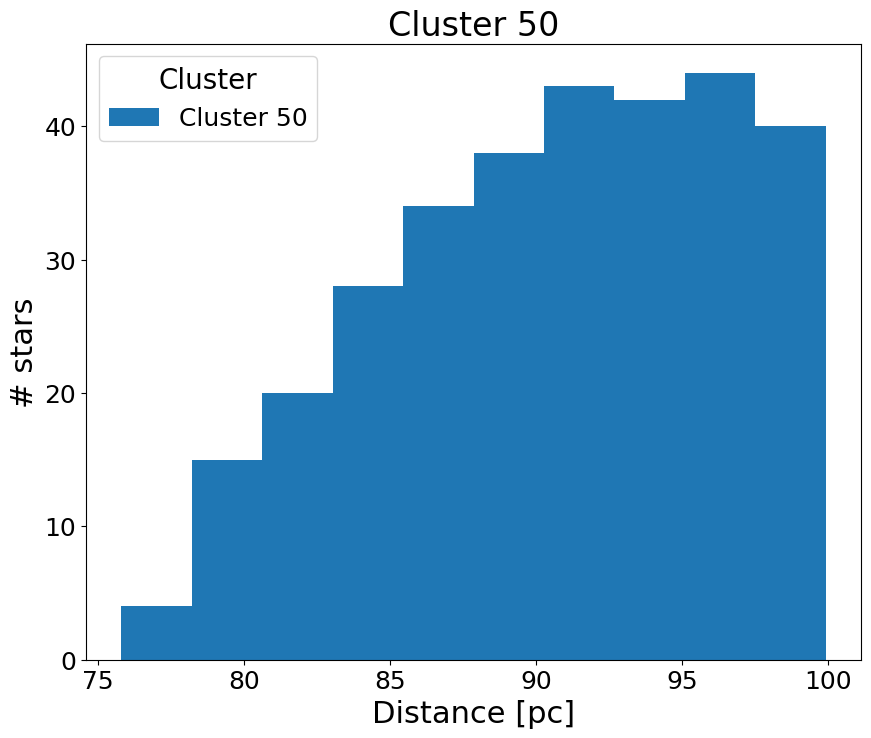

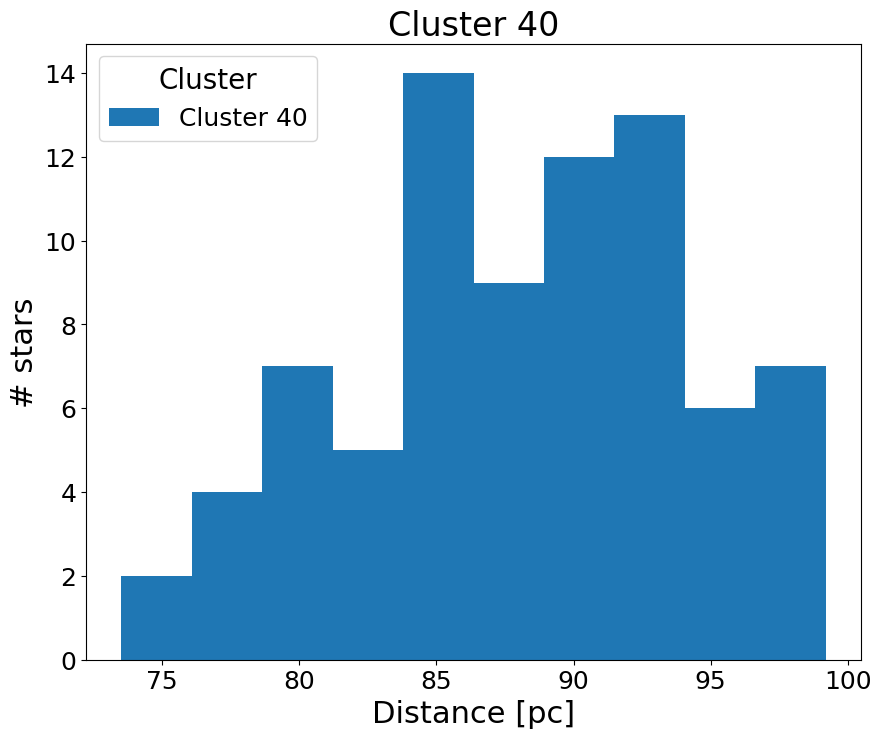

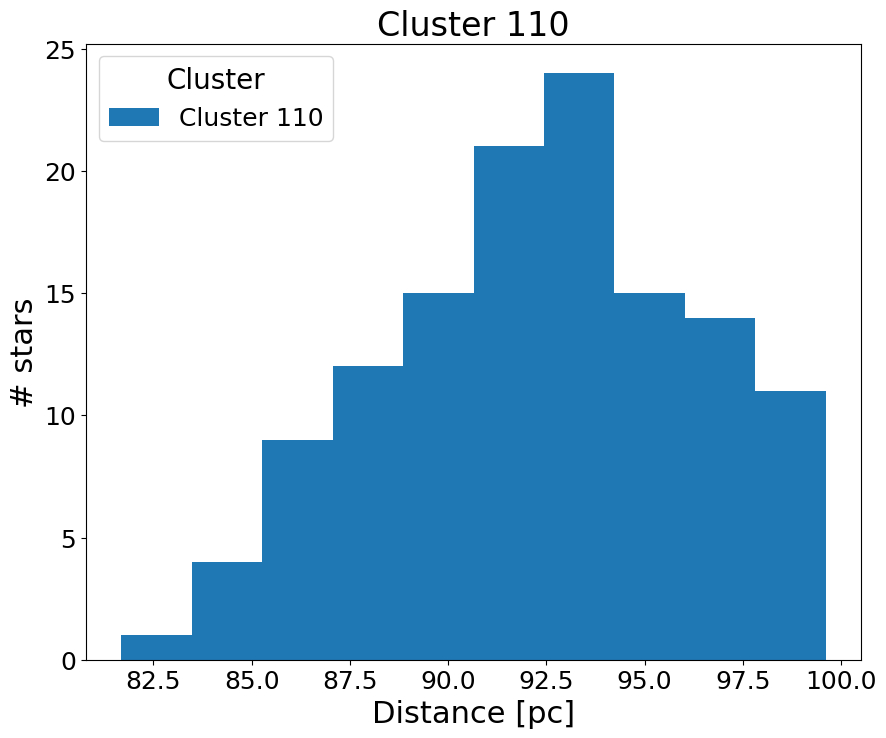

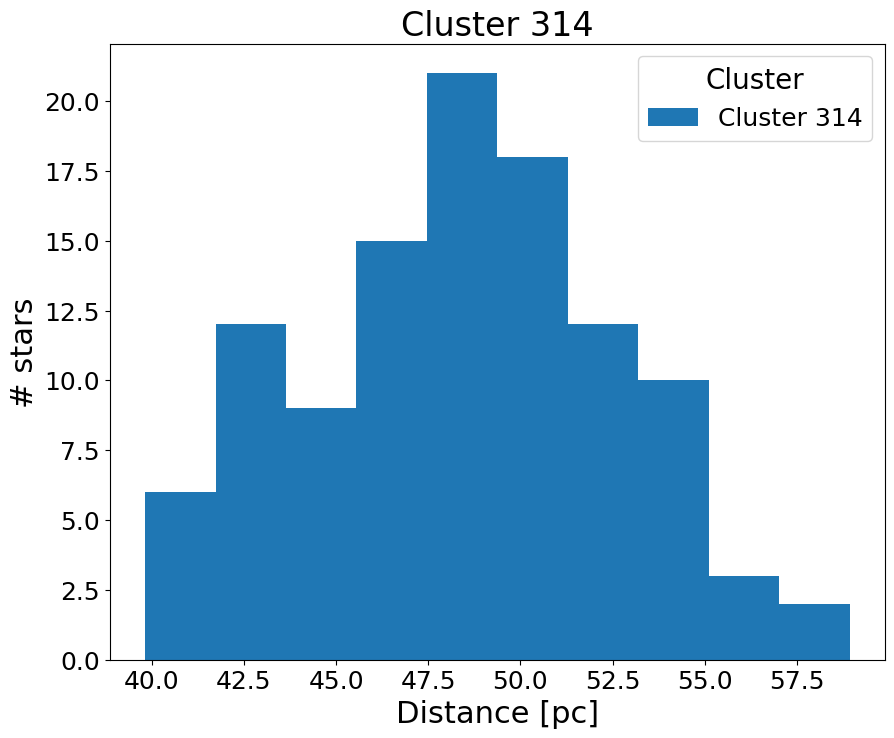

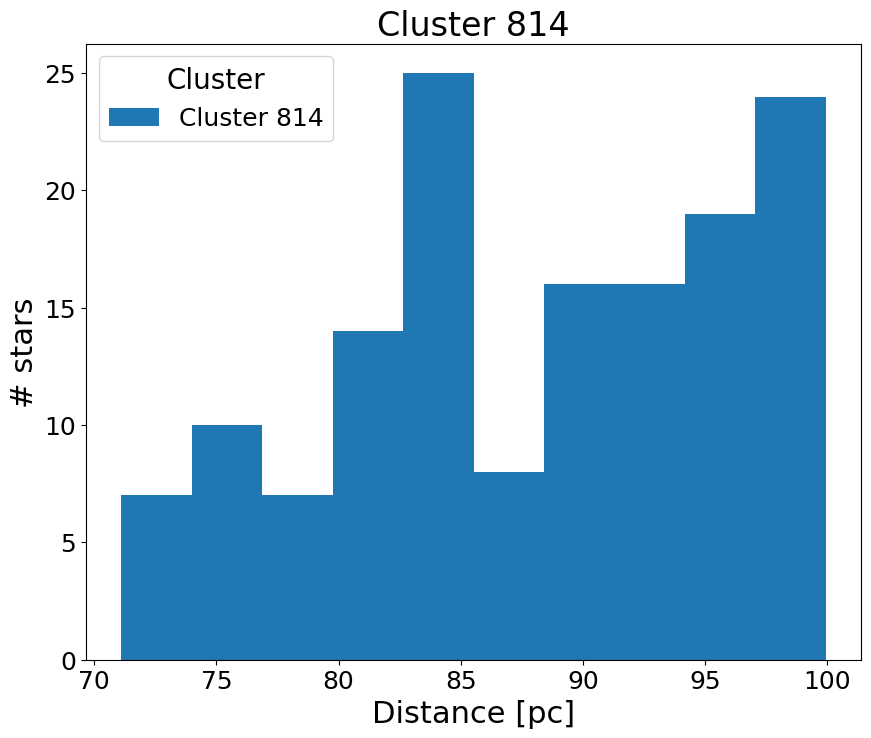

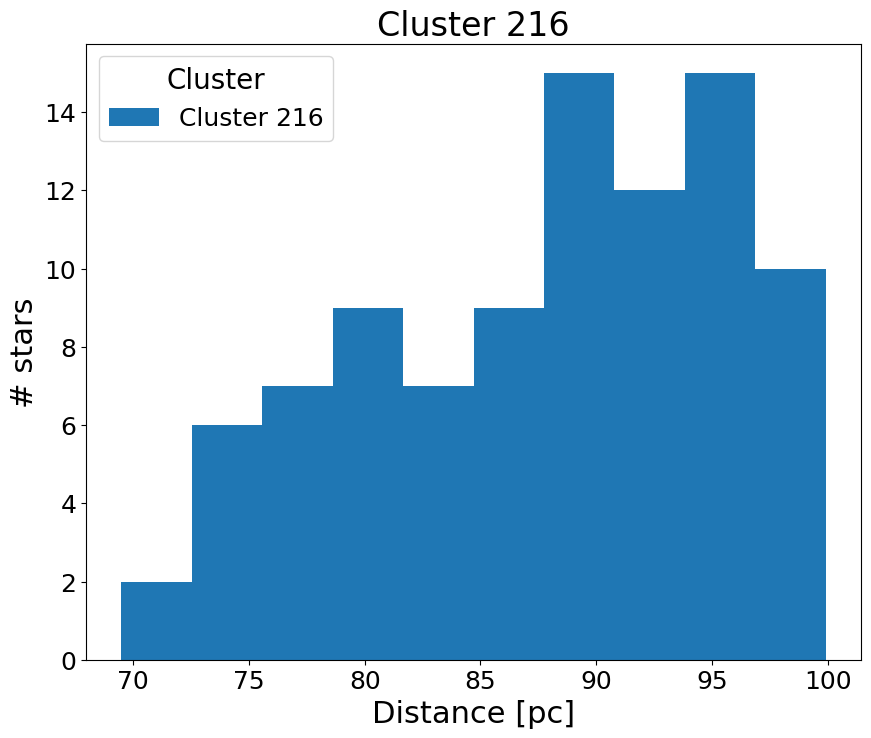

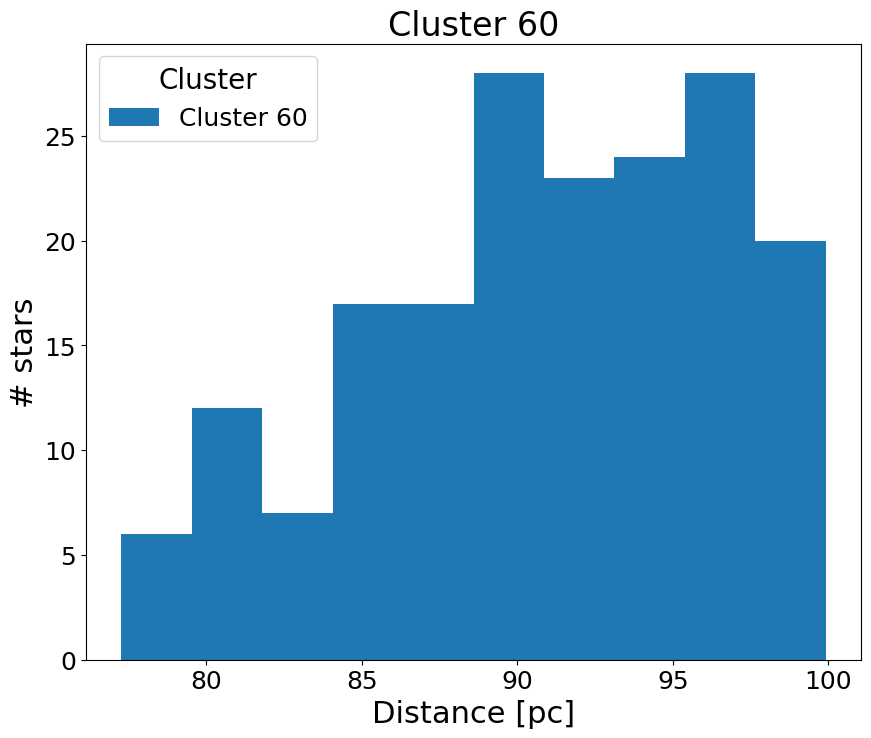

In [113]:
for cluster in silhouette_por_cluster.sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0]).head(25)['cluster'].values:
    subset = dff[dff['cluster'] == cluster]
    if cluster == 8:
        cluster  = "8 Hyades"
    if cluster == 7:
        cluster  = "7 Coma Berenices"
    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['fidelity_v2']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis
    plt.figure(figsize = (10,8))
    # Crear scatter plot con color en función de la probabilidad
    sc = plt.hist(1000/subset['parallax'],
                     label=f'Cluster {cluster}')

    plt.xlabel('Distance [pc]')
    plt.ylabel('# stars')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')

    # plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.savefig(f"figures/parallax_histogram_{cluster}.png")
    plt.show()

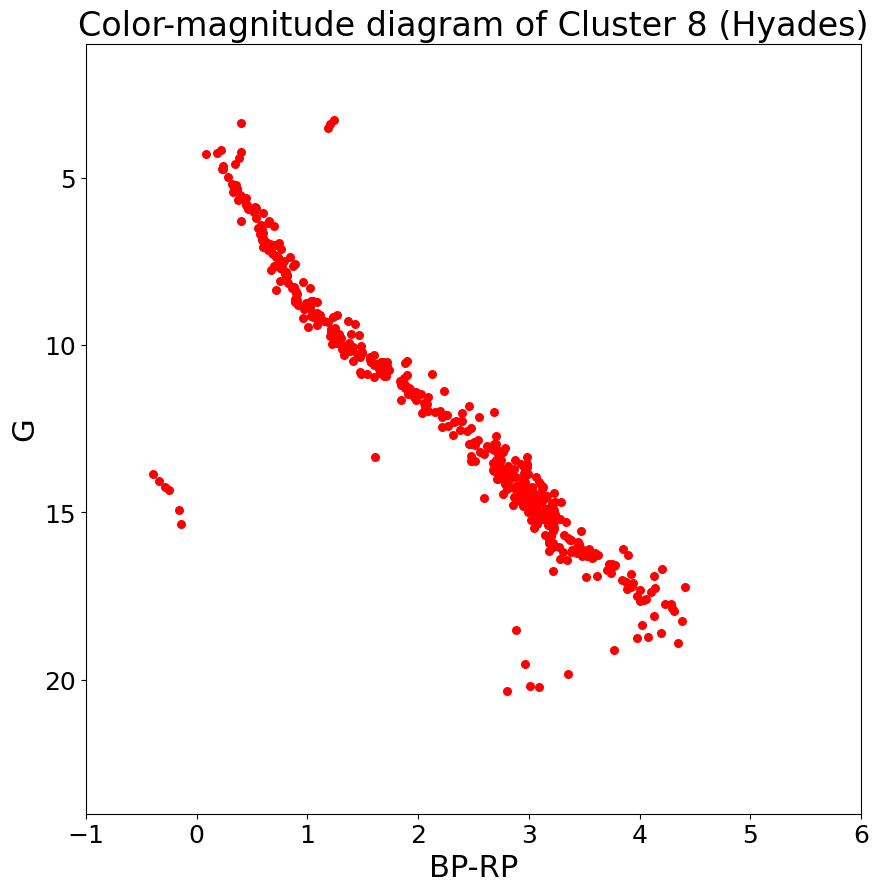

In [114]:
df_hyades = dff[dff['cluster'] == 8]
plt.figure(figsize=(10, 10))
plt.scatter(df_hyades['bp_rp'], df_hyades['phot_g_mean_mag'], c='red', s=30)
plt.xlabel('BP-RP')
plt.ylabel('G')
plt.title('Color-magnitude diagram of Cluster 8 (Hyades)')
plt.xlim(-1,6)
plt.ylim(1,24)
plt.gca().invert_yaxis()
plt.savefig(f"figures/diagrama_cm_hyades.png")
plt.show()

In [115]:
silhouette_por_cluster[(silhouette_por_cluster["probabilidad"]>0.3)
                       &(silhouette_por_cluster["silhouette"]>0)].sort_values(by=['metrica','silhouette_distancia','silhouette','silhouette_movimientos','probabilidad'], ascending=[0,0,0,0,0])

,cluster,silhouette,probabilidad,source_id,silhouette_distancia,silhouette_movimientos,r2,rmse_phot_g_mean_mag_vs_bp_rp,dispersion_phot_g_mean_mag_std,silhouette_esc,silhouette_distancia_esc,silhouette_movimientos_esc,probabilidad_esc,r2_esc,rmse_phot_g_mean_mag_vs_bp_rp_esc,metrica
3,8,0.647723,0.79500,476,0.836569,-0.243567,0.711165,1.472356,3.716733,4.854431,5.000000,2.295296,4.953125,5.000000,1.998319,0.472976
2,7,0.523314,0.78875,248,0.752236,0.045685,0.580405,1.919328,3.921752,4.333991,4.680639,3.560467,4.914062,4.080663,2.750778,0.344369
1,4,0.170438,0.70375,76,0.755369,-0.548303,0.278696,2.136096,3.101930,2.857804,4.692504,0.962401,4.382812,1.959430,3.115699,0.148152
6,13,0.161702,0.61500,183,0.628189,-0.459525,0.248948,2.012059,2.827635,2.821258,4.210887,1.350714,3.828125,1.750282,2.906888,0.096178
23,113,0.435493,0.37625,78,0.569737,0.374802,0.138171,2.074437,2.634048,3.966610,3.989537,5.000000,2.335937,0.971444,3.011899,0.029619
8,16,0.682521,0.46250,215,0.380812,-0.585635,0.104648,2.760387,3.372202,5.000000,3.274099,0.799114,2.875000,0.735751,4.166668,0.018431
12,28,0.206016,0.80250,78,0.074759,-0.235563,0.011763,1.259929,1.320631,3.006640,2.115112,2.330308,5.000000,0.082706,1.640707,0.000706
34,514,0.046466,0.40250,427,0.475592,-0.471756,0.000599,0.324313,0.327083,2.339192,3.633021,1.297213,2.500000,0.004211,0.065634,0.000115
22,112,0.479174,0.73875,192,0.309610,0.232619,0.000414,2.064236,2.085945,4.149339,3.004464,4.378101,4.601562,0.002910,2.994725,0.000095
31,316,0.051894,0.62625,108,0.300740,0.118959,0.000340,0.311153,0.336217,2.361901,2.970874,3.880963,3.898438,0.002391,0.043481,0.000064


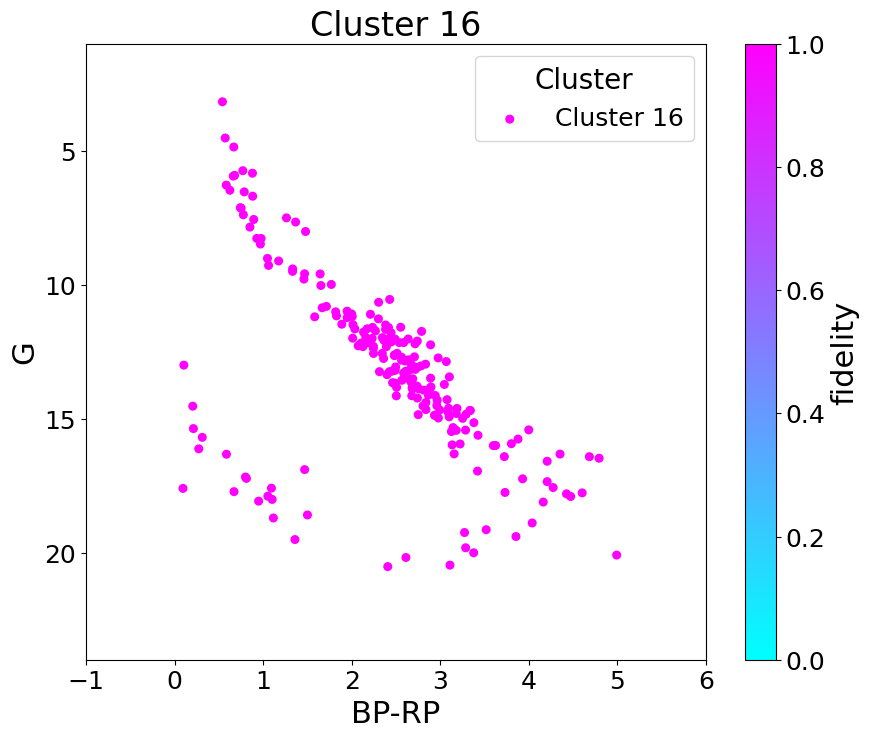

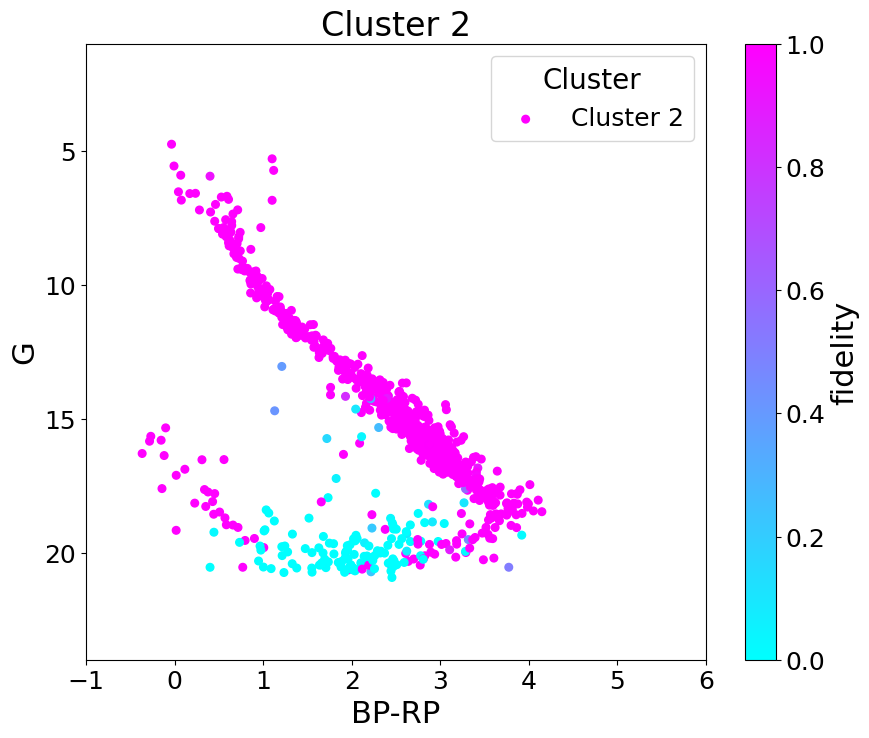

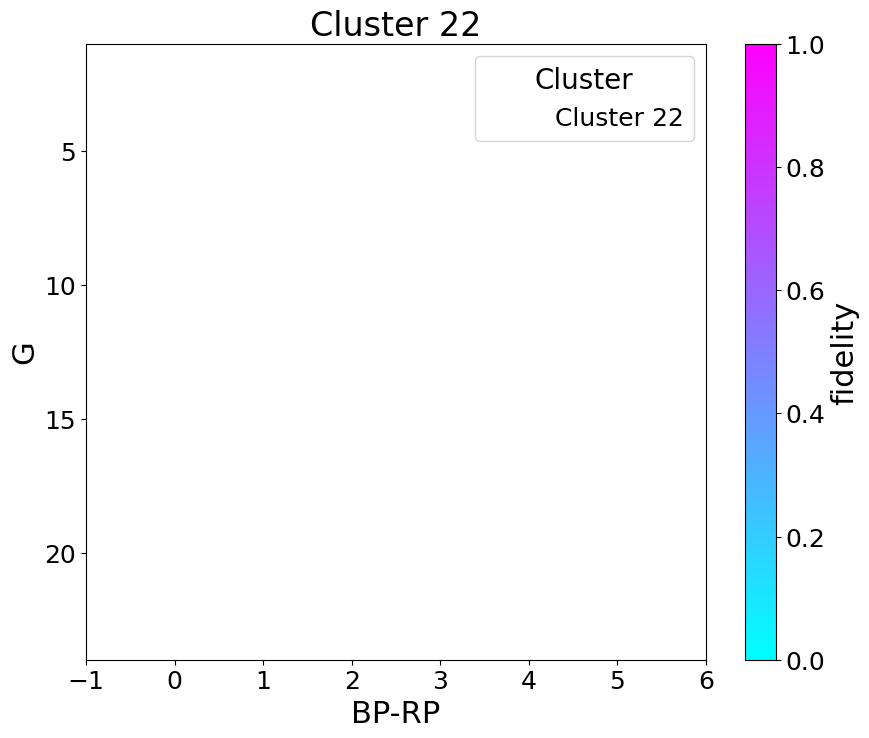

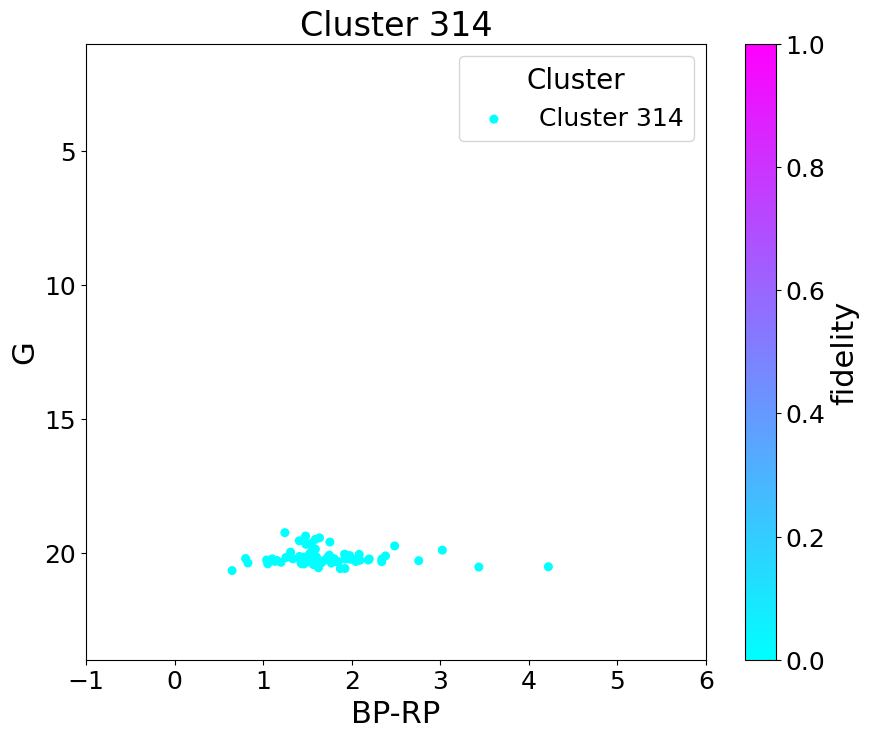

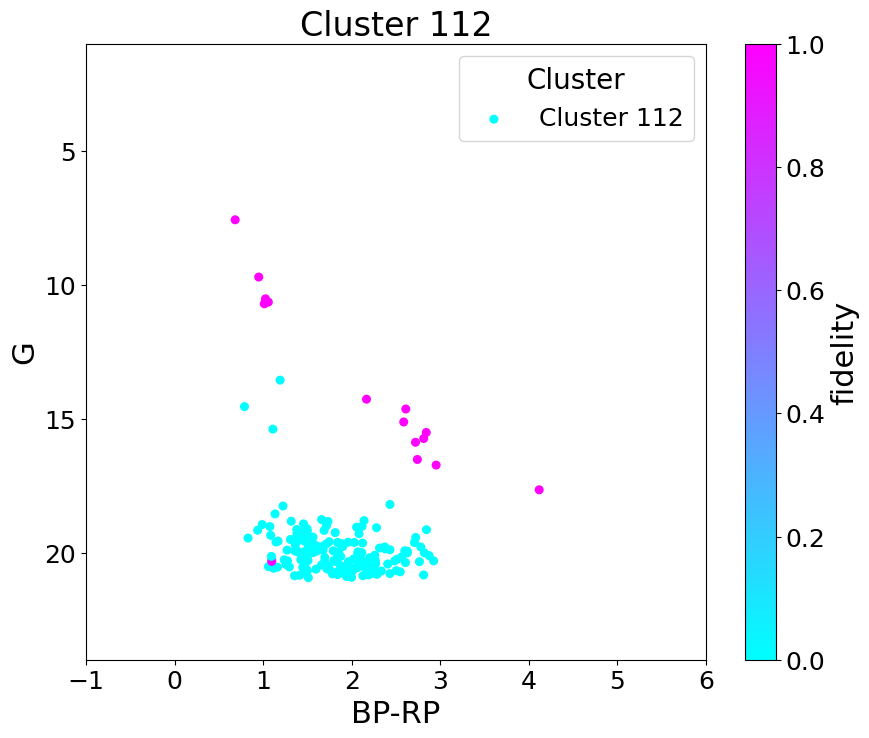

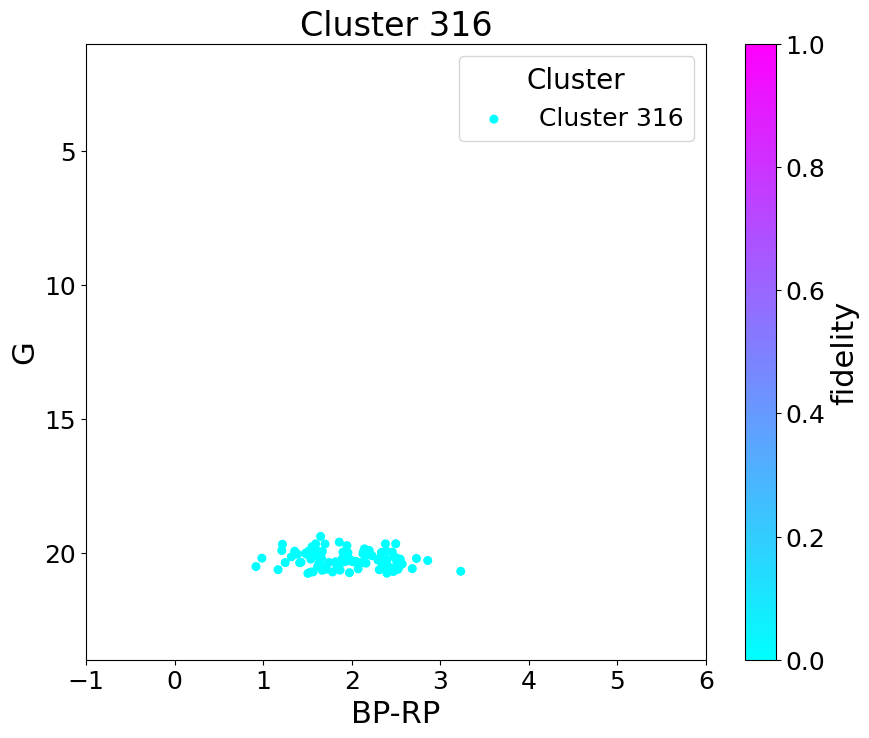

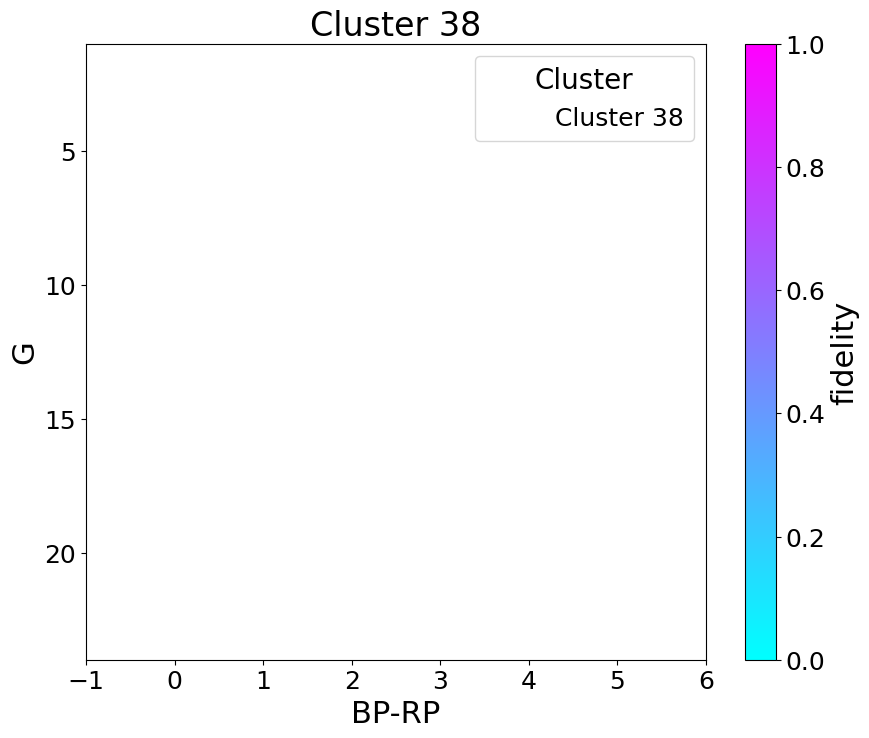

In [116]:
for cluster in [16,2,22,314,112,316,38]:
    subset = dff[dff['cluster'] == cluster]
    if cluster == 8:
        cluster  = "8 Hyades"
    if cluster == 7:
        cluster  = "7 Coma Berenices"
    # Dibujar ruido en negro con alfa fijo
    noise = dff[dff['cluster'] < 0]
    plt.figure(figsize = (10,8))
    # plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['fidelity_v2']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.cool

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(-1,6)
    plt.ylim(1,24)
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('fidelity')

    plt.savefig(f"../data/ruta_imagenes_evolucion/diagrama_cluster_fidelity_{cluster}.png")
    plt.show()

In [157]:
silhouette_por_cluster[['cluster','distance_pc_median']]

,cluster,distance_pc_median
0,2,92.103730
1,4,92.397498
2,7,86.479266
3,8,47.671185
4,10,84.983393
6,13,92.032578
8,16,38.972225
9,17,90.249186
12,28,87.323701
13,30,91.827145


In [154]:
radius_metrics[radius_metrics['cluster'].isin([112,4,13,16])]

,cluster,radio_mean,radio_median,radio_std,radius_effective
1,4,10.818653,10.445070,3.501582,10.445070
6,13,12.433639,11.966206,4.270786,11.966206
8,16,12.787467,12.047247,5.063661,12.047247
22,112,12.705933,12.749573,4.885237,12.749573
